# Predicting 30-Day Hospital Readmission in Diabetic Patients
**Dataset:** Diabetes 130-US Hospitals (1999–2008) — UCI ML Repository (ID 296)  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Problem:** Binary classification — will a diabetic inpatient be readmitted within 30 days?

---


## 0. Environment Setup

In [1]:
# Uncomment to install if needed
#!pip install scikit-learn imbalanced-learn xgboost shap scipy pandas numpy matplotlib seaborn


In [2]:
#!pip install numpy scikit-learn --upgrade --trusted-host pypi.org --trusted-host files.pythonhosted.org

In [3]:
#!pip install "pandas>=2.0" --trusted-host pypi.org --trusted-host files.pythonhosted.org

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Core ML
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# Statistical testing
from scipy.stats import wilcoxon

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COLORS  = ['#4C72B0', '#DD8452', '#55A868']   # LR, RF, XGB
PALETTE = {'Logistic Regression': '#4C72B0',
           'Random Forest':       '#DD8452',
           'XGBoost':             '#55A868'}

print("All libraries loaded.")


All libraries loaded.


## 1. Data Loading

Place `diabetic_data.csv` in the same folder as this notebook (or adjust the path below).  
**Source:** [UCI ML Repository — Dataset 296](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)


In [5]:
df_raw = pd.read_csv(
    'https://raw.githubusercontent.com/mahdi2382/Module_5/main/diabetic_data.csv',
    na_values=['?', 'Unknown/Invalid', 'None'],
    low_memory=False
)
print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")
print(f"\nTarget distribution (raw):")
print(df_raw['readmitted'].value_counts())
print(f"\nMissing values (top 10):")
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))


Loaded: 101,766 rows x 50 cols

Target distribution (raw):
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Missing values (top 10):
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
gender                   3
dtype: int64


In [6]:
df_raw.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Preprocessing

Pipeline steps:
1. **Deduplication** — one encounter per patient (keep earliest encounter_id)
2. **Drop** identifier and high-missingness columns
3. **Remove** hospice/expired discharges — cannot be readmitted
4. **Drop** near-zero-variance medication columns
5. **Binary target** — `<30` days = 1, else = 0
6. **Age** — ordinal midpoint encoding
7. **Medication columns** — Steady/No → 0, Up/Down → 1
8. **A1Cresult & max_glu_serum** — ordinal encoding preserving clinical ordering
9. **Diagnosis codes** — ICD-9 grouped into 9 clinical categories
10. **Label encode** remaining categoricals; median impute residual NAs

Race is saved *before* encoding for the fairness audit in Section 12.


In [7]:
df = df_raw.copy()

# 1. Deduplication — one encounter per patient (earliest admission)
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f"After deduplication: {df.shape[0]:,} rows")

# 2. Drop ID and high-missingness columns
drop_cols = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# 3. Remove hospice/expired discharges
hospice_codes = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(hospice_codes)]
print(f"After hospice removal: {df.shape[0]:,} rows")

# 4. Drop near-zero-variance medication columns
zero_var_meds = ['examide', 'citoglipton', 'acetohexamide',
                 'troglitazone', 'tolazamide', 'tolbutamide']
df.drop(columns=[c for c in zero_var_meds if c in df.columns], inplace=True)

# 5. Binary target
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)
vc = df['readmitted_binary'].value_counts()
print(f"\nClass balance: {vc[0]:,} negative | {vc[1]:,} positive | ratio {vc[0]/vc[1]:.1f}:1")

# 6. Age ordinal midpoint encoding
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_map)

# 7. Medication change columns
med_change_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'glipizide','glyburide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','insulin','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'
]
for col in med_change_cols:
    if col in df.columns:
        df[col] = df[col].map({'No': 0, 'Steady': 0, 'Up': 1, 'Down': 1}).fillna(0).astype(int)

# 8. Binary/ordinal categoricals
df['change']        = (df['change'] == 'Ch').astype(int)
df['diabetesMed']   = (df['diabetesMed'] == 'Yes').astype(int)
df['gender']        = df['gender'].map({'Male': 0, 'Female': 1})
df['A1Cresult']     = df['A1Cresult'].map({'None': 0, 'Norm': 1, '>7': 2, '>8': 3}).fillna(0)
df['max_glu_serum'] = df['max_glu_serum'].map({'None': 0, 'Norm': 1, '>200': 2, '>300': 3}).fillna(0)

# 9. ICD-9 diagnosis grouping into 9 clinical categories
def map_diag(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'): return 'Other'
        val = float(code)
        if 390 <= val <= 459 or val == 785:    return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:  return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:  return 'Digestive'
        elif 250 <= val < 251:                  return 'Diabetes'
        elif 800 <= val <= 999:                return 'Injury'
        elif 710 <= val <= 739:                return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:  return 'Genitourinary'
        elif 140 <= val <= 239:                return 'Neoplasms'
        else:                                  return 'Other'
    except:
        return 'Other'

for dcol in ['diag_1', 'diag_2', 'diag_3']:
    if dcol in df.columns:
        df[dcol] = df[dcol].apply(map_diag)
# Convert categorical ID columns from int to string so they're treated as nominal
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    if col in df.columns:
        df[col] = df[col].astype(str)
# 10. Save race before encoding for fairness audit
race_raw = df['race'].copy()

# Fill missing categorical strings with 'Missing' (NOT encoded yet — encoding happens in the pipeline)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Missing')

print(f"\nFinal shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Categorical (object) columns remaining: {list(df.select_dtypes(include='object').columns)}")
print(f"Missing values remaining (numeric): {df.select_dtypes(exclude='object').isnull().sum().sum()}")

After deduplication: 71,518 rows
After hospice removal: 69,973 rows

Class balance: 63,696 negative | 6,277 positive | ratio 10.1:1

Final shape: 69,973 rows x 39 cols
Categorical (object) columns remaining: ['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2', 'diag_3']
Missing values remaining (numeric): 3


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline

# Columns that are conceptually categorical (nominal) — must be one-hot encoded
nominal_cols = ['race', 'diag_1', 'diag_2', 'diag_3',
                'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

# Everything else is numeric/ordinal/binary
nominal_cols = [c for c in nominal_cols if c in df.columns]
numeric_cols = [c for c in df.columns
                if c not in nominal_cols + ['readmitted_binary']]

print(f"Nominal (one-hot): {len(nominal_cols)} columns → {nominal_cols}")
print(f"Numeric/ordinal:   {len(numeric_cols)} columns")

# Numeric: median impute
numeric_pipe = SklearnPipeline([
    ('impute', SimpleImputer(strategy='median'))
])

# Categorical: constant 'Missing' impute → one-hot encode
nominal_pipe = SklearnPipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', nominal_pipe, nominal_cols)
])

Nominal (one-hot): 7 columns → ['race', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']
Numeric/ordinal:   31 columns


In [9]:
df.describe().round(2)

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
count,69970.00,69973.00,69973.00,69973.00,69973.00,69973.00,69973.00,69973.00,69973.00,69973.00,...,69973.00,69973.0,69973.00,69973.0,69973.0,69973.0,69973.0,69973.00,69973.00,69973.00
mean,0.53,65.44,4.27,42.88,1.43,15.67,0.28,0.10,0.18,7.22,...,0.00,0.2,0.00,0.0,0.0,0.0,0.0,0.45,0.76,0.09
std,0.50,15.97,2.93,19.89,1.76,8.29,1.06,0.51,0.60,2.00,...,0.01,0.4,0.01,0.0,0.0,0.0,0.0,0.50,0.43,0.29
min,0.00,5.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00
25%,0.00,55.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,1.00,0.00
50%,1.00,65.00,3.00,44.00,1.00,14.00,0.00,0.00,0.00,8.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,1.00,0.00
75%,1.00,75.00,6.00,57.00,2.00,20.00,0.00,0.00,0.00,9.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,1.00,1.00,0.00
max,1.00,95.00,14.00,132.00,6.00,81.00,42.00,42.00,12.00,16.00,...,1.00,1.0,1.00,0.0,0.0,0.0,0.0,1.00,1.00,1.00


## 3. Exploratory Data Analysis

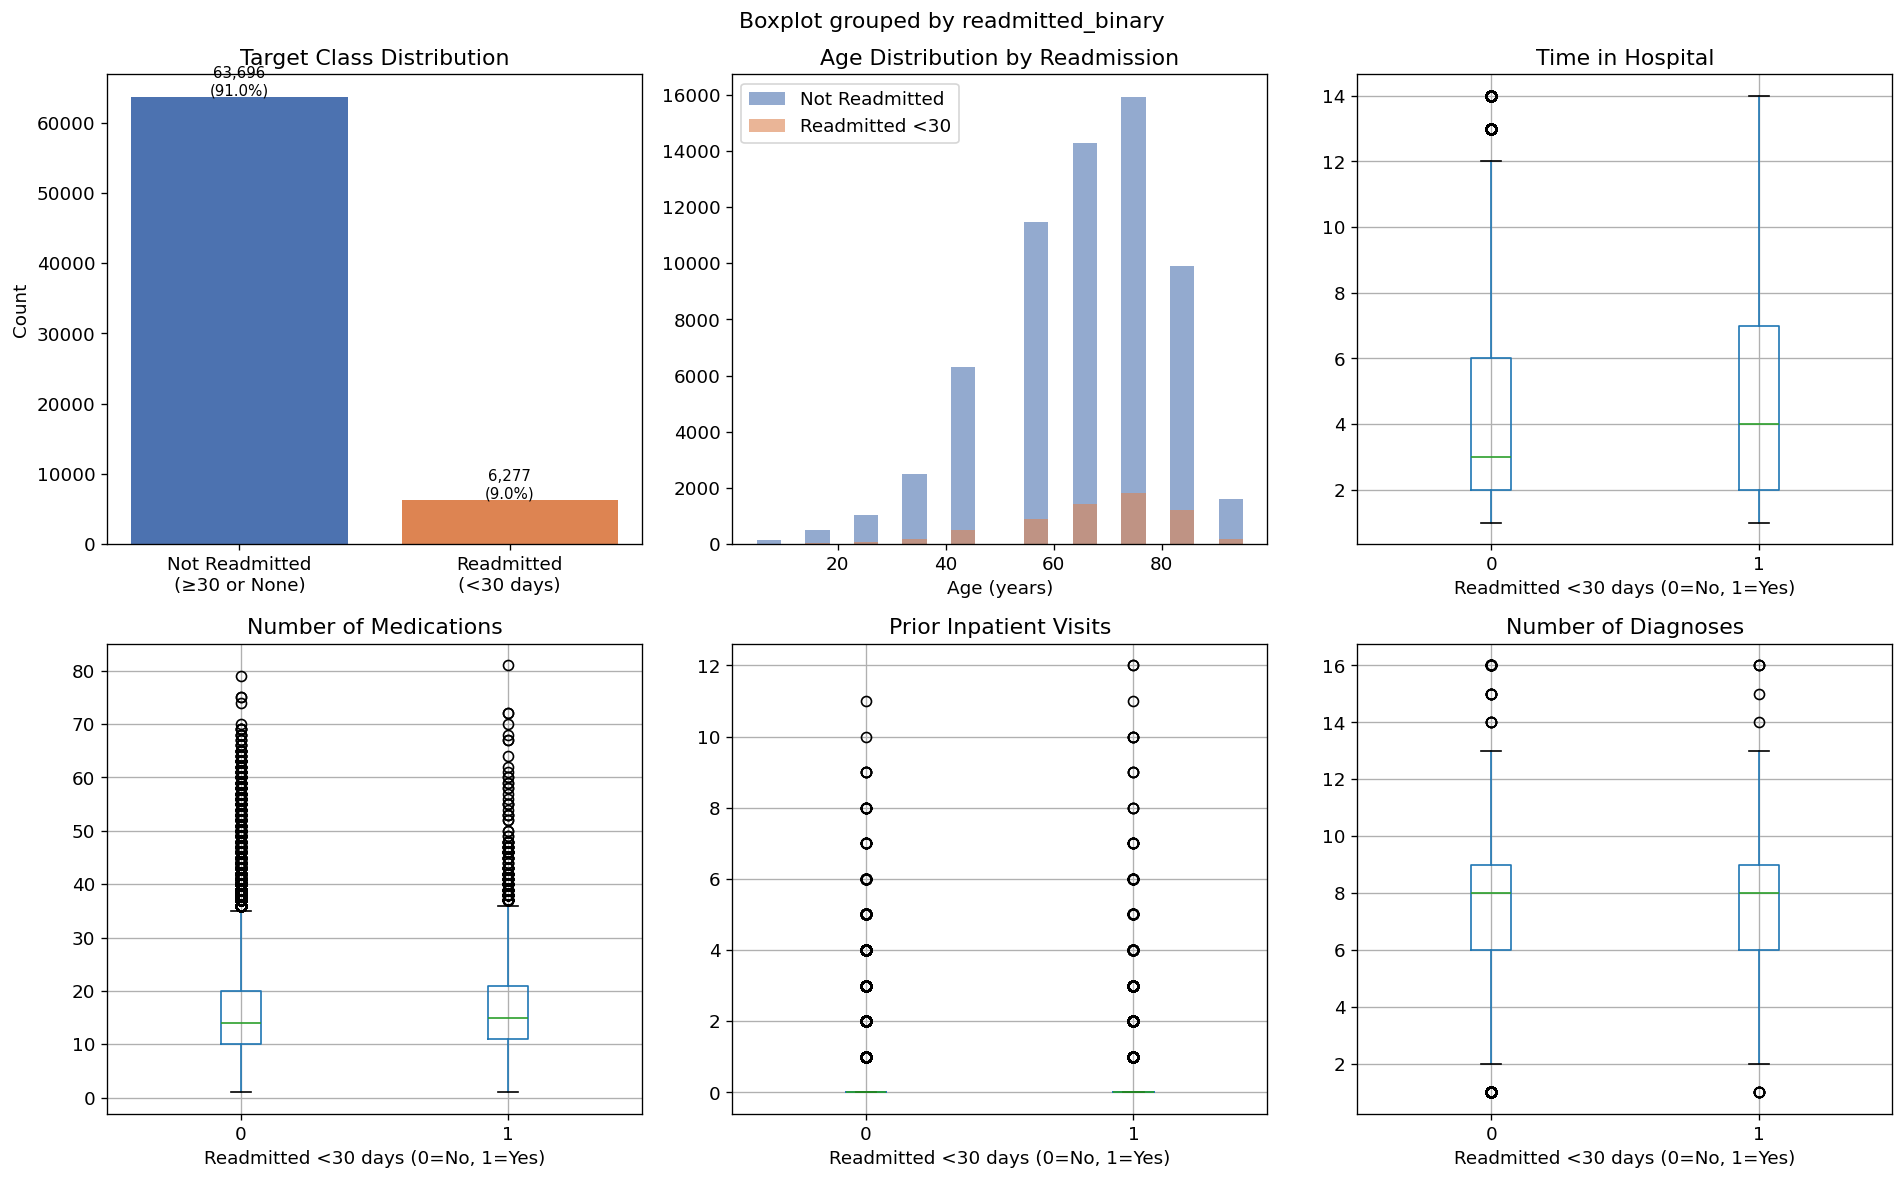

Saved: fig_eda.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Diabetes 130-US Hospitals', fontsize=14, fontweight='bold')

# Class distribution
vc = df['readmitted_binary'].value_counts()
axes[0,0].bar(['Not Readmitted\n(≥30 or None)', 'Readmitted\n(<30 days)'], vc.values, color=COLORS[:2])
axes[0,0].set_title('Target Class Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0,0].text(i, v+200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Age distribution
for label, grp in df.groupby('readmitted_binary'):
    axes[0,1].hist(grp['age'], bins=20, alpha=0.6,
                   label='Readmitted <30' if label else 'Not Readmitted', color=COLORS[label])
axes[0,1].set_title('Age Distribution by Readmission')
axes[0,1].set_xlabel('Age (years)')
axes[0,1].legend()

# Time in hospital
df.boxplot(column='time_in_hospital', by='readmitted_binary', ax=axes[0,2])
plt.sca(axes[0,2])
plt.title('Time in Hospital')
axes[0,2].set_xlabel('Readmitted <30 days (0=No, 1=Yes)')

# Number of medications
df.boxplot(column='num_medications', by='readmitted_binary', ax=axes[1,0])
plt.sca(axes[1,0])
plt.title('Number of Medications')
axes[1,0].set_xlabel('Readmitted <30 days (0=No, 1=Yes)')

# Prior inpatient visits
df.boxplot(column='number_inpatient', by='readmitted_binary', ax=axes[1,1])
plt.sca(axes[1,1])
plt.title('Prior Inpatient Visits')
axes[1,1].set_xlabel('Readmitted <30 days (0=No, 1=Yes)')

# Number of diagnoses
df.boxplot(column='number_diagnoses', by='readmitted_binary', ax=axes[1,2])
plt.sca(axes[1,2])
plt.title('Number of Diagnoses')
axes[1,2].set_xlabel('Readmitted <30 days (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('fig_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_eda.png")


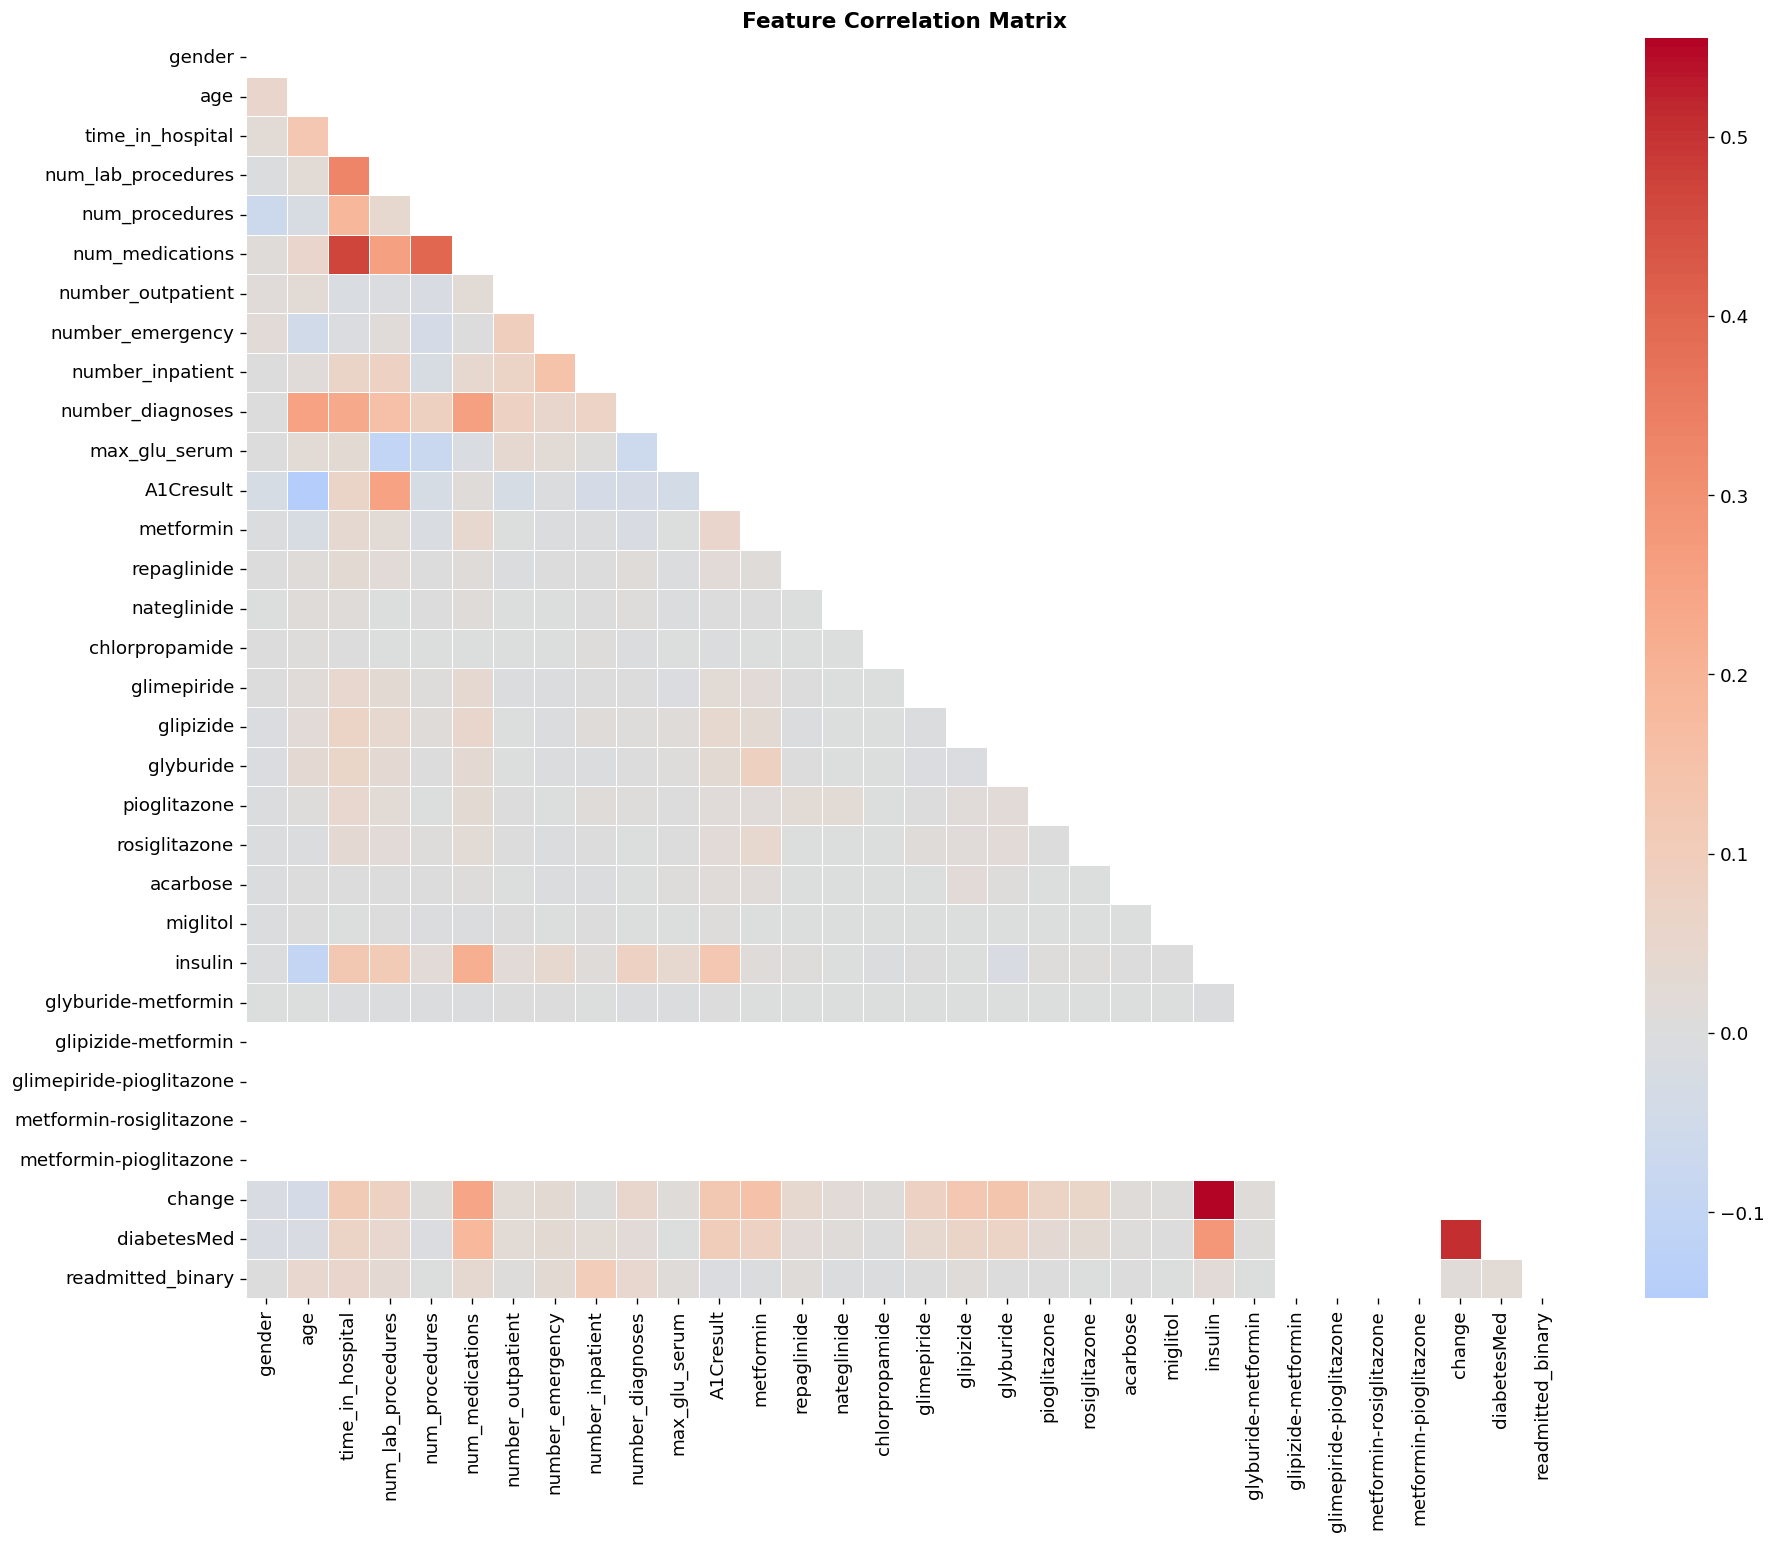

Saved: fig_correlation.png


In [11]:
# Correlation heatmap
corr = df.select_dtypes(include=[np.number]).corr()
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr,
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            cmap='coolwarm', center=0, annot=False, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_correlation.png")


## 4. Train/Test Split

- **80/20 stratified split** — preserves class ratio in both partitions  
- Imbalance is handled by class weighting inside the cross-validation pipeline (Section 6), not here  
- The test set is never touched by any resampling procedure


In [12]:
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
test_idx = X_test.index   # preserve for fairness audit

print(f"Training set: {X_train.shape[0]:,} rows  |  Test set: {X_test.shape[0]:,} rows")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


Training set: 55,978 rows  |  Test set: 13,995 rows
Train positive rate: 0.090  |  Test positive rate: 0.090


In [13]:
# race_raw was saved before label encoding — already contains original string values
race_test = race_raw.loc[test_idx].fillna('Missing')
race_decoded = race_test.rename('race')

print("Race distribution in test set:")
print(race_decoded.value_counts())

Race distribution in test set:
race
Caucasian          10509
AfricanAmerican     2504
Missing              364
Hispanic             299
Other                231
Asian                 88
Name: count, dtype: int64


## 5. Hyperparameter Search

`RandomizedSearchCV` with 5-fold stratified CV on the training set. Class imbalance is handled by model-internal weighting (`class_weight='balanced'` / `scale_pos_weight`) — no resampling.

Search spaces:
- **LR**: regularisation strength `C`
- **RF**: `n_estimators`, `max_depth`, `min_samples_leaf`  
- **XGBoost**: `n_estimators`, `max_depth`, `learning_rate`, `subsample`

This replaces arbitrary fixed hyperparameters with evidence-based selection.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Compute scale_pos_weight for XGBoost from the training-set imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos
print(f"Training imbalance: neg={neg:,}, pos={pos:,}, scale_pos_weight={scale_pos:.2f}")

# ── Logistic Regression: weighting only ──────────────────────────────────────
lr_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('scaler',     StandardScaler(with_mean=False)),
    ('model',      LogisticRegression(
        max_iter=2000, solver='lbfgs',
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

# ── Random Forest: weighting only ────────────────────────────────────────────
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model',      RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

# ── XGBoost: scale_pos_weight only ───────────────────────────────────────────
xgb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model',      XGBClassifier(
        scale_pos_weight=scale_pos, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ))
])

# ── Hyperparameter search ────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_param_dist = {
    'model__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
}
lr_search = RandomizedSearchCV(
    lr_pipe, lr_param_dist, n_iter=7, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

rf_param_dist = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [8, 10, 12, 15, None],
    'model__min_samples_leaf': [5, 10, 20, 30]
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=15, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

xgb_param_dist = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample':     [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=20, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

# Fit all three
print("Fitting Logistic Regression...")
lr_search.fit(X_train, y_train)
print(f"  Best CV AUC: {lr_search.best_score_:.4f}  |  Params: {lr_search.best_params_}")

print("\nFitting Random Forest...")
rf_search.fit(X_train, y_train)
print(f"  Best CV AUC: {rf_search.best_score_:.4f}  |  Params: {rf_search.best_params_}")

print("\nFitting XGBoost...")
xgb_search.fit(X_train, y_train)
print(f"  Best CV AUC: {xgb_search.best_score_:.4f}  |  Params: {xgb_search.best_params_}")

best_models = {
    'Logistic Regression': lr_search.best_estimator_,
    'Random Forest':       rf_search.best_estimator_,
    'XGBoost':             xgb_search.best_estimator_
}

Training imbalance: neg=50,956, pos=5,022, scale_pos_weight=10.15
Fitting Logistic Regression...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
  Best CV AUC: 0.6494  |  Params: {'model__C': 0.001}

Fitting Random Forest...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
  Best CV AUC: 0.6540  |  Params: {'model__n_estimators': 200, 'model__min_samples_leaf': 10, 'model__max_depth': None}

Fitting XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV AUC: 0.6511  |  Params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.05}


## 6. Stratified 5-Fold Cross-Validation

**Methodological note:** Class imbalance is handled using model weighting only: `class_weight='balanced'` for Logistic Regression and Random Forest, and `scale_pos_weight` for XGBoost. No resampling is used, avoiding double-correction and preserving the original data distribution in validation folds.

Metrics: AUC-ROC, F1, Precision, Recall (mean ± SD across 5 folds).


In [15]:
cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipeline in best_models.items():
    print(f"Cross-validating {name}...")
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv_eval,
        scoring=['roc_auc', 'f1', 'precision', 'recall'],
        n_jobs=-1
    )
    cv_results[name] = scores
    print(f"  AUC-ROC:   {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print(f"  F1:        {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    print(f"  Precision: {scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}")
    print(f"  Recall:    {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
    print()


Cross-validating Logistic Regression...
  AUC-ROC:   0.6494 ± 0.0059
  F1:        0.2220 ± 0.0031
  Precision: 0.1407 ± 0.0018
  Recall:    0.5261 ± 0.0111

Cross-validating Random Forest...
  AUC-ROC:   0.6540 ± 0.0056
  F1:        0.2111 ± 0.0062
  Precision: 0.2012 ± 0.0093
  Recall:    0.2224 ± 0.0068

Cross-validating XGBoost...
  AUC-ROC:   0.6511 ± 0.0052
  F1:        0.2224 ± 0.0037
  Precision: 0.1415 ± 0.0025
  Recall:    0.5195 ± 0.0078



In [16]:
# ── Statistical comparison of CV AUC scores ───────────────────────────────────
# Wilcoxon signed-rank test (non-parametric, paired across folds)
model_names = list(cv_results.keys())
print("Wilcoxon signed-rank tests on CV AUC-ROC fold scores:")
print(f"{'Comparison':<45} {'W-stat':>8} {'p-value':>10} {'Significant':>12}")
print("-" * 78)
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a = cv_results[model_names[i]]['test_roc_auc']
        b = cv_results[model_names[j]]['test_roc_auc']
        stat, p = wilcoxon(a, b)
        sig = "Yes (p<0.05)" if p < 0.05 else "No"
        label = f"{model_names[i]} vs {model_names[j]}"
        print(f"{label:<45} {stat:>8.1f} {p:>10.4f} {sig:>12}")


Wilcoxon signed-rank tests on CV AUC-ROC fold scores:
Comparison                                      W-stat    p-value  Significant
------------------------------------------------------------------------------
Logistic Regression vs Random Forest               1.0     0.1250           No
Logistic Regression vs XGBoost                     5.0     0.6250           No
Random Forest vs XGBoost                           4.0     0.4375           No


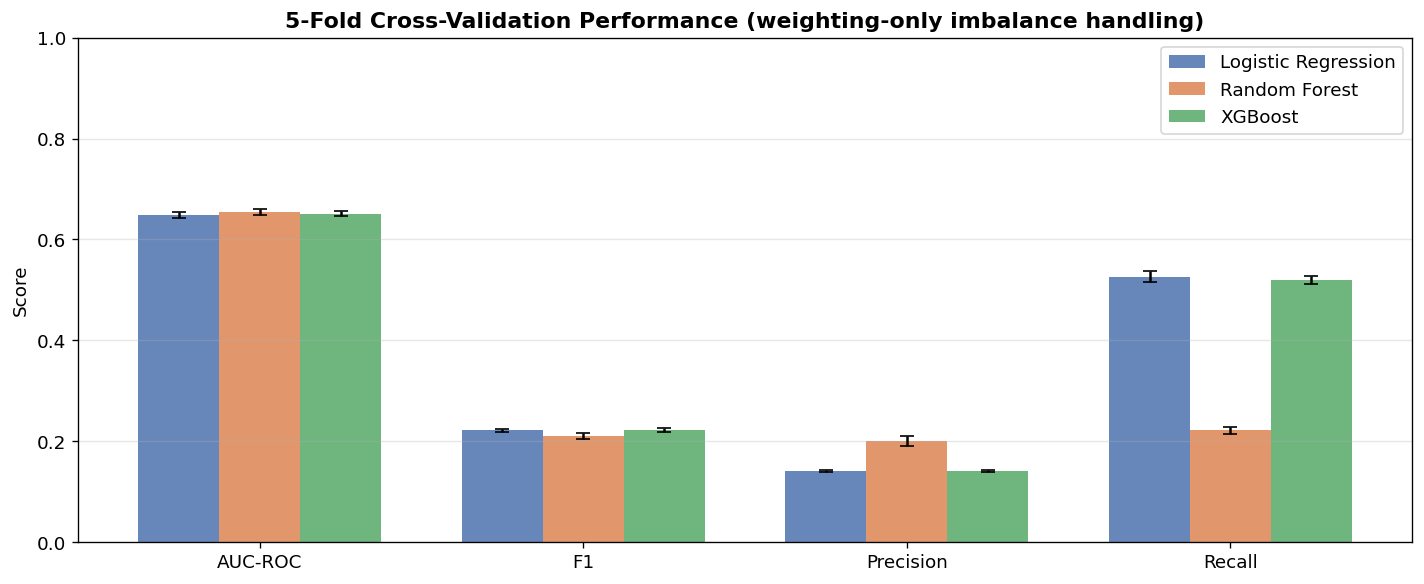

Saved: fig_cv_performance.png


In [17]:
# CV performance bar chart
metrics_map = {
    'test_roc_auc': 'AUC-ROC',
    'test_f1':      'F1',
    'test_precision': 'Precision',
    'test_recall':   'Recall'
}
x = np.arange(len(metrics_map))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, scores) in enumerate(cv_results.items()):
    means = [scores[m].mean() for m in metrics_map]
    stds  = [scores[m].std()  for m in metrics_map]
    ax.bar(x + i*width, means, width, yerr=stds,
           label=name, color=list(PALETTE.values())[i], alpha=0.85, capsize=4)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_map.values())
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('5-Fold Cross-Validation Performance (weighting-only imbalance handling)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_cv_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_cv_performance.png")


## 7. Final Evaluation on Held-Out Test Set

Models are retrained on the full training set with class-weighting/scale_pos_weight imbalance handling, then evaluated on the untouched test set which retains the original class imbalance (~10:1). This reflects real-world deployment conditions.


In [18]:
test_results = {}

for name, pipeline in best_models.items():
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    auprc   = average_precision_score(y_test, y_proba)
    brier   = brier_score_loss(y_test, y_proba)
    report  = classification_report(y_test, y_pred, output_dict=True)
    cm      = confusion_matrix(y_test, y_pred)

    test_results[name] = {
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'auc':     auc,
        'auprc':   auprc,
        'brier':   brier,
        'report':  report,
        'cm':      cm
    }

    print(f"{'='*60}")
    print(f"  {name}   AUC-ROC={auc:.4f}   AUPRC={auprc:.4f}   Brier={brier:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred,
          target_names=['Not Readmitted', 'Readmitted <30']))


  Logistic Regression   AUC-ROC=0.6488   AUPRC=0.1679   Brier=0.2284
                precision    recall  f1-score   support

Not Readmitted       0.93      0.68      0.79     12740
Readmitted <30       0.14      0.51      0.22      1255

      accuracy                           0.67     13995
     macro avg       0.54      0.60      0.50     13995
  weighted avg       0.86      0.67      0.74     13995

  Random Forest   AUC-ROC=0.6537   AUPRC=0.1774   Brier=0.1554
                precision    recall  f1-score   support

Not Readmitted       0.92      0.91      0.92     12740
Readmitted <30       0.21      0.24      0.23      1255

      accuracy                           0.85     13995
     macro avg       0.57      0.58      0.57     13995
  weighted avg       0.86      0.85      0.86     13995

  XGBoost   AUC-ROC=0.6508   AUPRC=0.1793   Brier=0.2163
                precision    recall  f1-score   support

Not Readmitted       0.94      0.68      0.79     12740
Readmitted <30      

## 8. Evaluation Visualisations

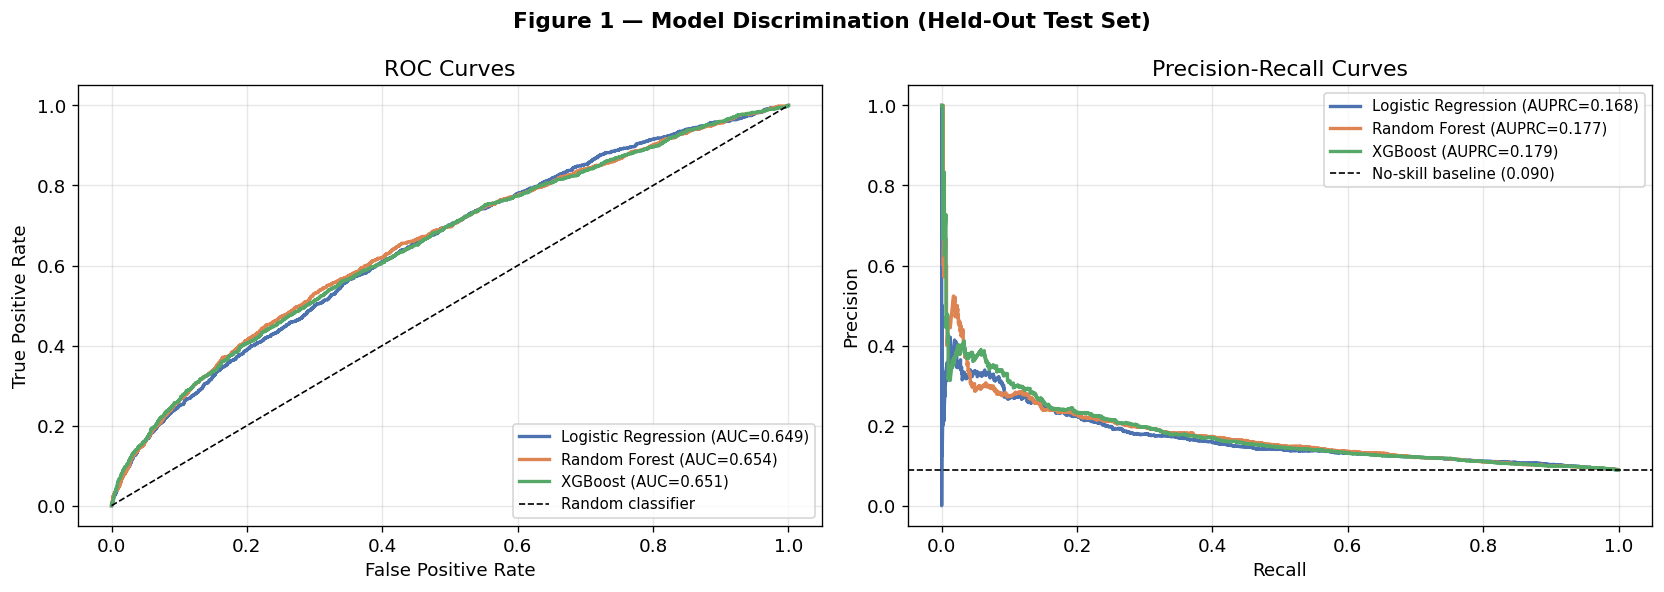

Saved: fig1_roc_pr.png


In [19]:
# ── Figure 1: ROC + Precision-Recall Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1 — Model Discrimination (Held-Out Test Set)',
             fontsize=13, fontweight='bold')

# ROC
ax = axes[0]
for i, (name, res) in enumerate(test_results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, lw=2, color=list(PALETTE.values())[i],
            label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Precision-Recall
ax = axes[1]
for i, (name, res) in enumerate(test_results.items()):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax.plot(rec, prec, lw=2, color=list(PALETTE.values())[i],
            label=f"{name} (AUPRC={res['auprc']:.3f})")
ax.axhline(y_test.mean(), color='k', linestyle='--', lw=1,
           label=f'No-skill baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_roc_pr.png")


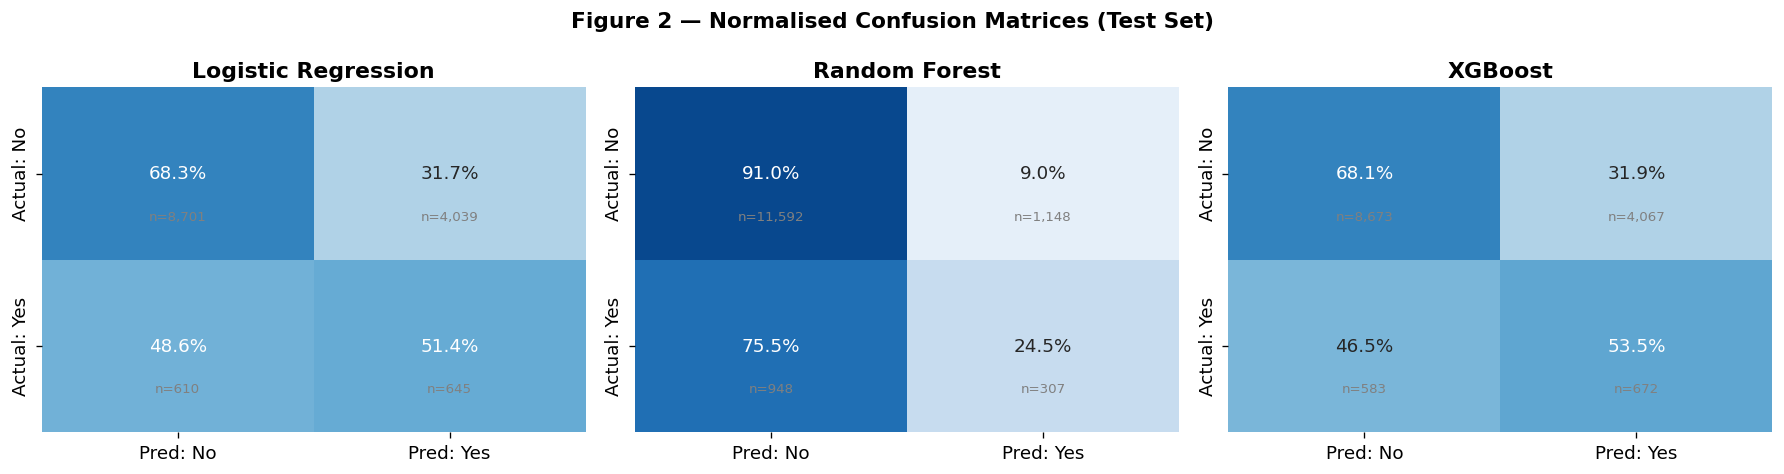

Saved: fig2_confusion_matrices.png


In [20]:
# ── Figure 2: Confusion Matrices ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figure 2 — Normalised Confusion Matrices (Test Set)',
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, test_results.items()):
    cm     = res['cm']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'],
                ax=ax, cbar=False, vmin=0, vmax=1)
    # Overlay raw counts
    for r in range(2):
        for c in range(2):
            ax.text(c + 0.5, r + 0.75, f'n={cm[r,c]:,}',
                    ha='center', va='center', fontsize=8, color='grey')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_confusion_matrices.png")


## 9. Probability Calibration

Class-weighting during model fitting shifts the decision boundary toward the minority class, which improves recall but inflates predicted probabilities. To recover clinically reliable risk estimates, isotonic regression is applied as a post-hoc calibration step, fitted within an internal 5-fold cross-validation on the training set only (no test-set leakage). Calibration is a methodologically central step here: it affects downstream Decision Curve Analysis, threshold selection, and fairness analysis.


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# Probability calibration: isotonic regression
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

print("Fitting isotonic-calibrated models...")
calibrated_models = {}
for name, pipe in best_models.items():
    cal = CalibratedClassifierCV(clone(pipe), method='isotonic', cv=5, n_jobs=-1)
    cal.fit(X_train, y_train)
    calibrated_models[name] = cal
    print(f"  {name}: calibrated")

# Test-set predictions, uncalibrated + calibrated
uncal_results = {}
cal_results   = {}
for name, pipe in best_models.items():
    yp_u = pipe.predict_proba(X_test)[:, 1]
    yp_c = calibrated_models[name].predict_proba(X_test)[:, 1]
    uncal_results[name] = {'y_proba': yp_u,
                           'auc':   roc_auc_score(y_test, yp_u),
                           'auprc': average_precision_score(y_test, yp_u),
                           'brier': brier_score_loss(y_test, yp_u)}
    cal_results[name]   = {'y_proba': yp_c,
                           'auc':   roc_auc_score(y_test, yp_c),
                           'auprc': average_precision_score(y_test, yp_c),
                           'brier': brier_score_loss(y_test, yp_c)}

no_skill_brier = y_test.mean() * (1 - y_test.mean())
print("\n" + "="*80)
print(f"{'Model':<22}{'AUC (cal/uncal)':<24}{'AUPRC (cal/uncal)':<24}{'Brier (cal/uncal)':<24}")
print("-"*80)
for name in best_models:
    u, c = uncal_results[name], cal_results[name]
    print(f"{name:<22}"
          f"{c['auc']:.4f} / {u['auc']:.4f}        "
          f"{c['auprc']:.4f} / {u['auprc']:.4f}        "
          f"{c['brier']:.4f} / {u['brier']:.4f}")
print(f"\nNo-skill Brier baseline: {no_skill_brier:.4f}")


Fitting isotonic-calibrated models...
  Logistic Regression: calibrated
  Random Forest: calibrated
  XGBoost: calibrated

Model                 AUC (cal/uncal)         AUPRC (cal/uncal)       Brier (cal/uncal)       
--------------------------------------------------------------------------------
Logistic Regression   0.6494 / 0.6488        0.1678 / 0.1679        0.0792 / 0.2284
Random Forest         0.6566 / 0.6537        0.1775 / 0.1774        0.0788 / 0.1554
XGBoost               0.6545 / 0.6508        0.1785 / 0.1793        0.0788 / 0.2163

No-skill Brier baseline: 0.0816


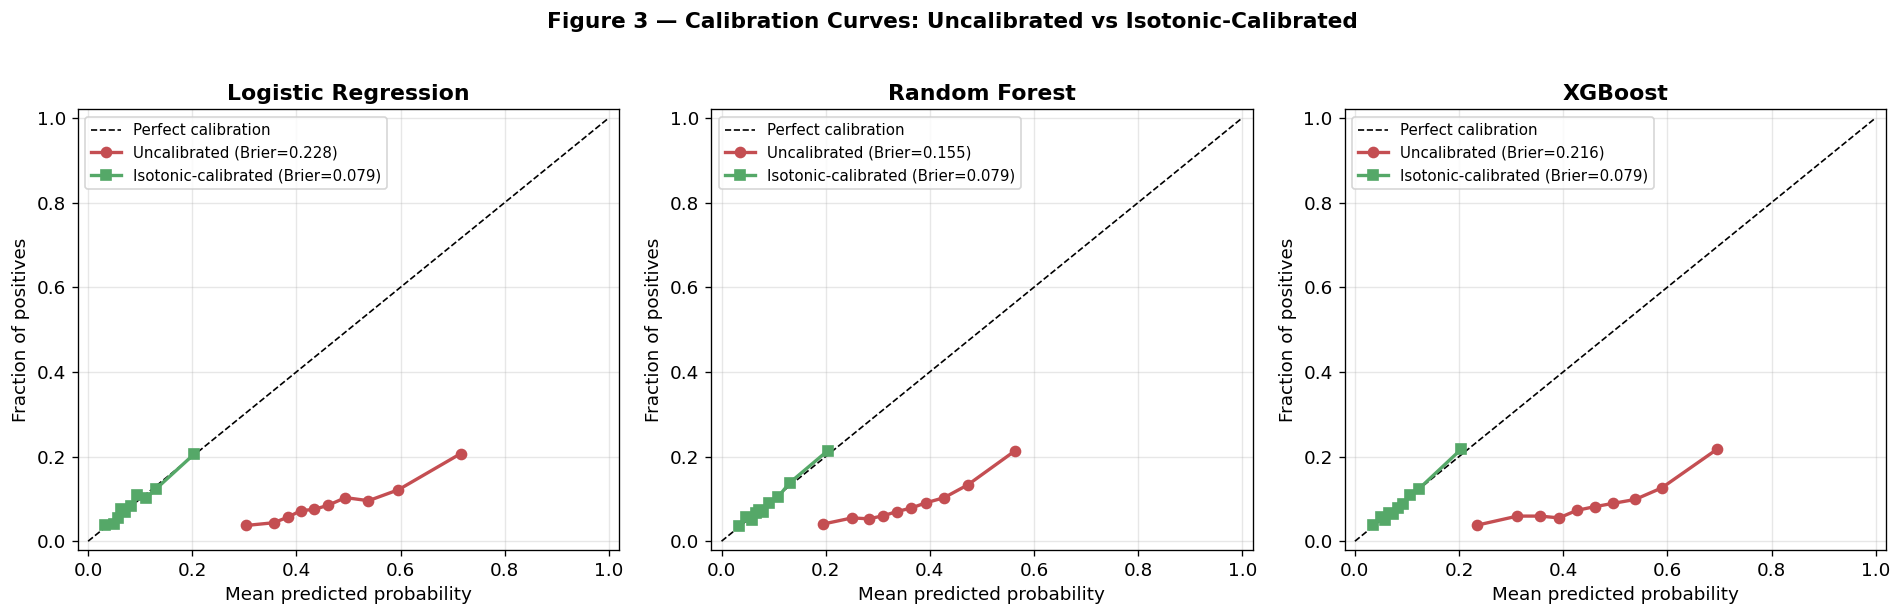

Saved: fig3_calibration.png


In [22]:
# ── Figure 3: Calibration Curves before/after isotonic calibration ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pipe) in zip(axes, best_models.items()):
    yp_u = uncal_results[name]['y_proba']
    yp_c = cal_results[name]['y_proba']
    brier_u = uncal_results[name]['brier']
    brier_c = cal_results[name]['brier']

    frac_u, mean_u = calibration_curve(y_test, yp_u, n_bins=10, strategy='quantile')
    frac_c, mean_c = calibration_curve(y_test, yp_c, n_bins=10, strategy='quantile')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.plot(mean_u, frac_u, 'o-', color='#C44E52', lw=2,
            label=f"Uncalibrated (Brier={brier_u:.3f})")
    ax.plot(mean_c, frac_c, 's-', color='#55A868', lw=2,
            label=f"Isotonic-calibrated (Brier={brier_c:.3f})")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle('Figure 3 — Calibration Curves: Uncalibrated vs Isotonic-Calibrated',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_calibration.png")


## 10. Decision Curve Analysis (DCA)

DCA converts model predictions into **net benefit** across a range of clinical decision thresholds.  
Net benefit = (TP rate) − (FP rate × threshold / (1 − threshold))

A model is clinically useful if its net benefit exceeds:
- the "treat all" strategy (assume every patient is high-risk)
- the "treat none" strategy (net benefit = 0)

This is increasingly required in clinical ML evaluation (Vickers & Elkin, 2006).


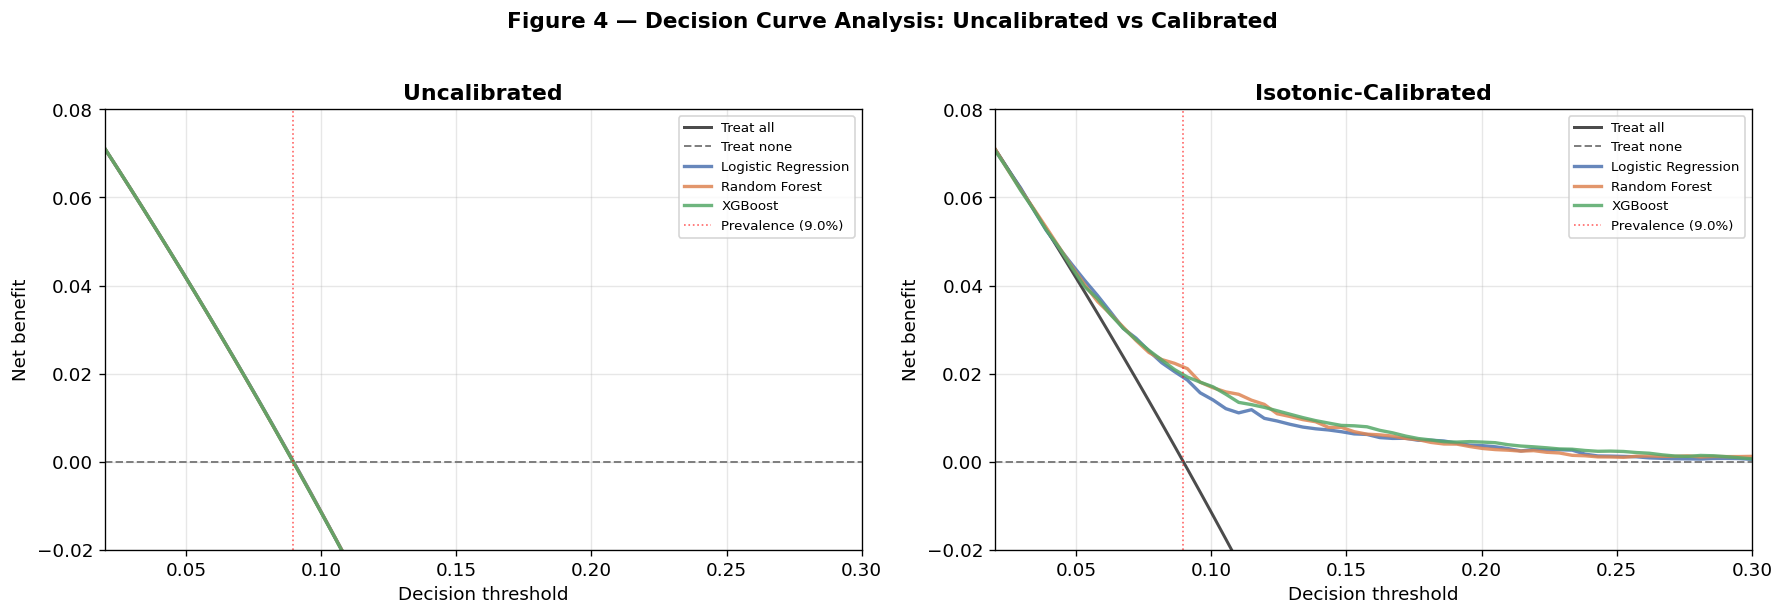

Saved: fig4_dca.png

Calibrated net benefit at key clinical thresholds:
Threshold   Treat-all   Logistic Regression   Random Forest         XGBoost               
0.048       0.0433      0.0448                0.0443                0.0440                
0.101       -0.0122     0.0140                0.0168                0.0170                
0.148       -0.0686     0.0068                0.0078                0.0082                
0.200       -0.1384     0.0036                0.0030                0.0044                


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# Figure 4 — Decision Curve Analysis: uncalibrated vs calibrated
# ═══════════════════════════════════════════════════════════════════════════════
def net_benefit(y_true, y_prob, threshold):
    y_pred_t = (y_prob >= threshold).astype(int)
    tp = ((y_pred_t == 1) & (y_true == 1)).sum()
    fp = ((y_pred_t == 1) & (y_true == 0)).sum()
    n  = len(y_true)
    return tp/n - fp/n * (threshold / (1 - threshold))

thresholds = np.linspace(0.02, 0.30, 60)
n_pos = y_test.sum()
n     = len(y_test)
treat_all = np.array([n_pos/n - (n - n_pos)/n * (t / (1 - t)) for t in thresholds])

nb_uncal = {name: np.array([net_benefit(y_test.values, uncal_results[name]['y_proba'], t)
                            for t in thresholds]) for name in best_models}
nb_cal   = {name: np.array([net_benefit(y_test.values, cal_results[name]['y_proba'], t)
                            for t in thresholds]) for name in best_models}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for ax, nb_dict, title in [(ax1, nb_uncal, 'Uncalibrated'),
                            (ax2, nb_cal, 'Isotonic-Calibrated')]:
    ax.plot(thresholds, treat_all, 'k-', lw=1.8, label='Treat all', alpha=0.7)
    ax.axhline(0, color='grey', linestyle='--', lw=1.2, label='Treat none')
    for i, (name, nbs) in enumerate(nb_dict.items()):
        ax.plot(thresholds, nbs, lw=2, color=list(PALETTE.values())[i],
                label=name, alpha=0.85)
    ax.axvline(n_pos/n, color='red', linestyle=':', lw=1, alpha=0.6,
               label=f'Prevalence ({n_pos/n:.1%})')
    ax.set_xlim(0.02, 0.30); ax.set_ylim(-0.02, 0.08)
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Net benefit')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('Figure 4 — Decision Curve Analysis: Uncalibrated vs Calibrated',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_dca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_dca.png")

# Net benefit at key thresholds
print("\nCalibrated net benefit at key clinical thresholds:")
print(f"{'Threshold':<12}{'Treat-all':<12}", end='')
for name in nb_cal: print(f"{name:<22}", end='')
print()
for t_target in [0.05, 0.10, 0.15, 0.20]:
    idx = np.argmin(np.abs(thresholds - t_target))
    print(f"{thresholds[idx]:<12.3f}{treat_all[idx]:<12.4f}", end='')
    for name in nb_cal:
        print(f"{nb_cal[name][idx]:<22.4f}", end='')
    print()


### Per-subgroup calibration

A model can be well-calibrated overall while being poorly calibrated within specific subgroups, a fairness concern documented in clinical ML literature (Obermeyer et al., 2019). Brier scores are computed by racial subgroup for both uncalibrated and isotonic-calibrated predictions, against subgroup-specific no-skill baselines.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# Per-subgroup calibration (Brier scores by race)
# ═══════════════════════════════════════════════════════════════════════════════
subgroup_calib = []
for name in calibrated_models:
    yp_u = uncal_results[name]['y_proba']
    yp_c = cal_results[name]['y_proba']
    for race_val in race_decoded.unique():
        mask = race_decoded == race_val
        if mask.sum() < 30: continue
        y_r  = y_test[mask]
        if y_r.nunique() < 2: continue
        prev    = y_r.mean()
        noskill = prev * (1 - prev)
        brier_u = brier_score_loss(y_r, yp_u[mask.values])
        brier_c = brier_score_loss(y_r, yp_c[mask.values])
        subgroup_calib.append({
            'Model':   name,
            'Race':    race_val,
            'N':       int(mask.sum()),
            'Prev':    round(prev, 3),
            'NoSkill': round(noskill, 4),
            'Brier_U': round(brier_u, 4),
            'Brier_C': round(brier_c, 4),
            'BeatsBaseline': brier_c < noskill
        })

subgroup_calib_df = pd.DataFrame(subgroup_calib)
print("Per-subgroup Brier scores: uncalibrated vs calibrated\n")
for name in calibrated_models:
    sub = subgroup_calib_df[subgroup_calib_df['Model'] == name]
    print(f"── {name} ──")
    print(sub[['Race', 'N', 'Prev', 'NoSkill', 'Brier_U', 'Brier_C', 'BeatsBaseline']].to_string(index=False))
    print()
subgroup_calib_df.to_csv('subgroup_calibration.csv', index=False)
print("Saved: subgroup_calibration.csv")


Per-subgroup Brier scores: uncalibrated vs calibrated

── Logistic Regression ──
           Race     N  Prev  NoSkill  Brier_U  Brier_C  BeatsBaseline
AfricanAmerican  2504 0.090   0.0818   0.2203   0.0798           True
      Caucasian 10509 0.091   0.0830   0.2331   0.0805           True
          Other   231 0.048   0.0454   0.1951   0.0453           True
       Hispanic   299 0.097   0.0876   0.2001   0.0853           True
          Asian    88 0.125   0.1094   0.1876   0.1054           True
        Missing   364 0.052   0.0495   0.2012   0.0476           True

── Random Forest ──
           Race     N  Prev  NoSkill  Brier_U  Brier_C  BeatsBaseline
AfricanAmerican  2504 0.090   0.0818   0.1479   0.0792           True
      Caucasian 10509 0.091   0.0830   0.1595   0.0803           True
          Other   231 0.048   0.0454   0.1273   0.0436           True
       Hispanic   299 0.097   0.0876   0.1349   0.0822           True
          Asian    88 0.125   0.1094   0.1461   0.1072    

### Threshold Optimisation

The default 0.5 decision threshold is inappropriate for calibrated models on imbalanced data, since calibrated probabilities for a 9%-prevalence cohort rarely exceed 0.20. Operating thresholds are instead selected on out-of-fold cross-validation predictions on the training set, then applied once to the held-out test set. Two operating points are evaluated: an F1-optimal threshold and a recall-prioritising threshold (subject to precision ≥ 0.15).


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# Threshold optimisation on validation predictions
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score

print("Selecting thresholds from out-of-fold CV predictions...\n")

threshold_results = []
optimal_thresholds = {}

for name, cal_model in calibrated_models.items():
    # Out-of-fold predictions on training data (true held-out estimates of probability)
    yp_oof = cross_val_predict(cal_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

    # Sweep thresholds, pick optimal-F1 and optimal-recall-with-precision-floor
    ts = np.linspace(0.05, 0.50, 91)
    f1_scores  = [f1_score(y_train, yp_oof >= t)        for t in ts]
    rec_scores = [recall_score(y_train, yp_oof >= t)    for t in ts]
    pre_scores = [precision_score(y_train, yp_oof >= t, zero_division=0) for t in ts]

    t_f1    = ts[np.argmax(f1_scores)]
    # Recall-prioritising: max recall subject to precision >= 0.15
    valid   = [(t, r) for t, r, p in zip(ts, rec_scores, pre_scores) if p >= 0.15]
    t_rec   = max(valid, key=lambda x: x[1])[0] if valid else 0.5

    optimal_thresholds[name] = {'f1': t_f1, 'recall_priority': t_rec}

    # Now evaluate at three thresholds on the TEST set
    yp_test = cal_model.predict_proba(X_test)[:, 1]
    for thr_name, thr in [('Default (0.5)', 0.5),
                          (f'F1-optimal ({t_f1:.2f})', t_f1),
                          (f'Recall-priority ({t_rec:.2f})', t_rec)]:
        y_pred = (yp_test >= thr).astype(int)
        threshold_results.append({
            'Model':     name,
            'Threshold': thr_name,
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
            'Recall':    round(recall_score(y_test, y_pred), 3),
            'F1':        round(f1_score(y_test, y_pred), 3),
            'Flagged_pct': round(100 * y_pred.mean(), 1)
        })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))
threshold_df.to_csv('threshold_optimisation.csv', index=False)
print("\nSaved: threshold_optimisation.csv")

Selecting thresholds from out-of-fold CV predictions...

              Model              Threshold  Precision  Recall    F1  Flagged_pct
Logistic Regression          Default (0.5)      0.200   0.001 0.002          0.0
Logistic Regression      F1-optimal (0.12)      0.172   0.322 0.224         16.8
Logistic Regression Recall-priority (0.11)      0.148   0.433 0.221         26.2
      Random Forest          Default (0.5)      0.500   0.001 0.002          0.0
      Random Forest      F1-optimal (0.11)      0.166   0.450 0.243         24.3
      Random Forest Recall-priority (0.10)      0.152   0.504 0.234         29.7
            XGBoost          Default (0.5)      0.750   0.002 0.005          0.0
            XGBoost      F1-optimal (0.12)      0.177   0.361 0.238         18.3
            XGBoost Recall-priority (0.10)      0.155   0.496 0.236         28.8

Saved: threshold_optimisation.csv


## 11. Feature Importance — Random Forest (MDI) & XGBoost

MDI (Mean Decrease in Impurity) quantifies average reduction in node impurity attributed to each feature across all trees. Note: MDI can be inflated for high-cardinality or correlated features — SHAP values (Section 11) provide a more reliable directional attribution.


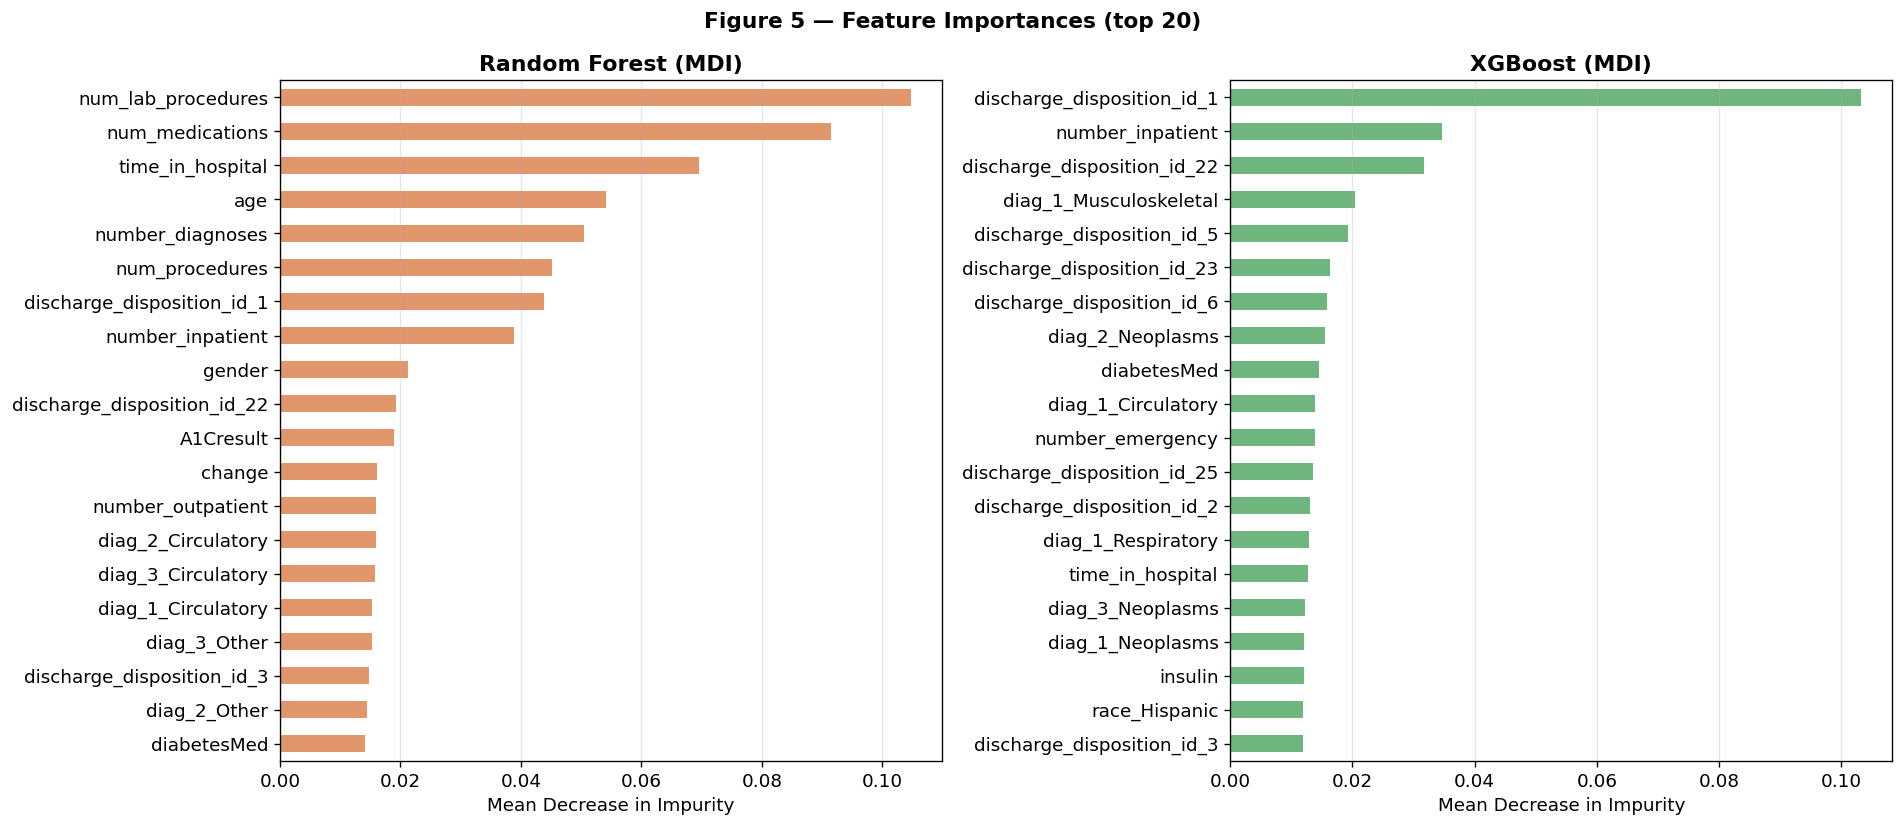

Saved: fig5_feature_importance.png

Random Forest Top 10 features (MDI):
num_lab_procedures             0.1047
num_medications                0.0915
time_in_hospital               0.0696
age                            0.0541
number_diagnoses               0.0506
num_procedures                 0.0452
discharge_disposition_id_1     0.0439
number_inpatient               0.0388
gender                         0.0213
discharge_disposition_id_22    0.0193

XGBoost Top 10 features (MDI):
discharge_disposition_id_1     0.1032
number_inpatient               0.0346
discharge_disposition_id_22    0.0317
diag_1_Musculoskeletal         0.0204
discharge_disposition_id_5     0.0192
discharge_disposition_id_23    0.0163
discharge_disposition_id_6     0.0158
diag_2_Neoplasms               0.0155
diabetesMed                    0.0146
diag_1_Circulatory             0.0139


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 5 — Feature Importances (top 20)', fontsize=13, fontweight='bold')

for ax, model_name, color in zip(axes,
                                  ['Random Forest', 'XGBoost'],
                                  [COLORS[1], COLORS[2]]):
    pipe       = best_models[model_name]
    estimator  = pipe.named_steps['model']
    feat_names = pipe.named_steps['preprocess'].get_feature_names_out()
    # Strip the 'num__' / 'cat__' prefix added by ColumnTransformer
    feat_names = [n.split('__', 1)[1] if '__' in n else n for n in feat_names]

    imp = pd.Series(estimator.feature_importances_, index=feat_names).sort_values(ascending=False)
    imp.head(20).sort_values().plot(kind='barh', color=color, alpha=0.85, ax=ax)
    ax.set_title(f'{model_name} (MDI)', fontweight='bold')
    ax.set_xlabel('Mean Decrease in Impurity')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_feature_importance.png")

# Print Top 10 for both models
for model_name in ['Random Forest', 'XGBoost']:
    pipe       = best_models[model_name]
    estimator  = pipe.named_steps['model']
    feat_names = pipe.named_steps['preprocess'].get_feature_names_out()
    feat_names = [n.split('__', 1)[1] if '__' in n else n for n in feat_names]
    imp = pd.Series(estimator.feature_importances_, index=feat_names).sort_values(ascending=False)
    print(f"\n{model_name} Top 10 features (MDI):")
    print(imp.head(10).round(4).to_string())

## 12. SHAP Interpretability

SHAP (SHapley Additive exPlanations) provides directional, interaction-aware feature attribution grounded in cooperative game theory. Unlike MDI, SHAP values are consistent and locally accurate — each value represents the contribution of a feature to a specific prediction.

The beeswarm plot shows: feature on y-axis; SHAP value on x-axis (positive = increases predicted readmission risk); colour = feature value (red = high, blue = low).


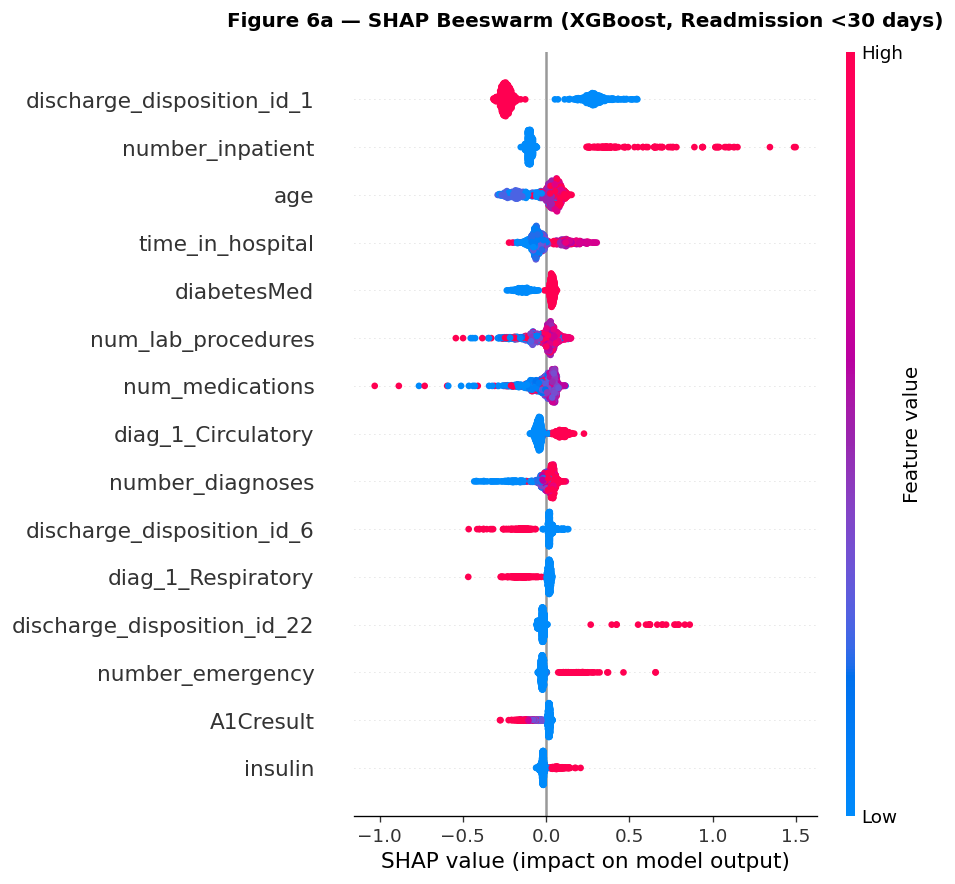

Saved: fig6a_shap_beeswarm.png


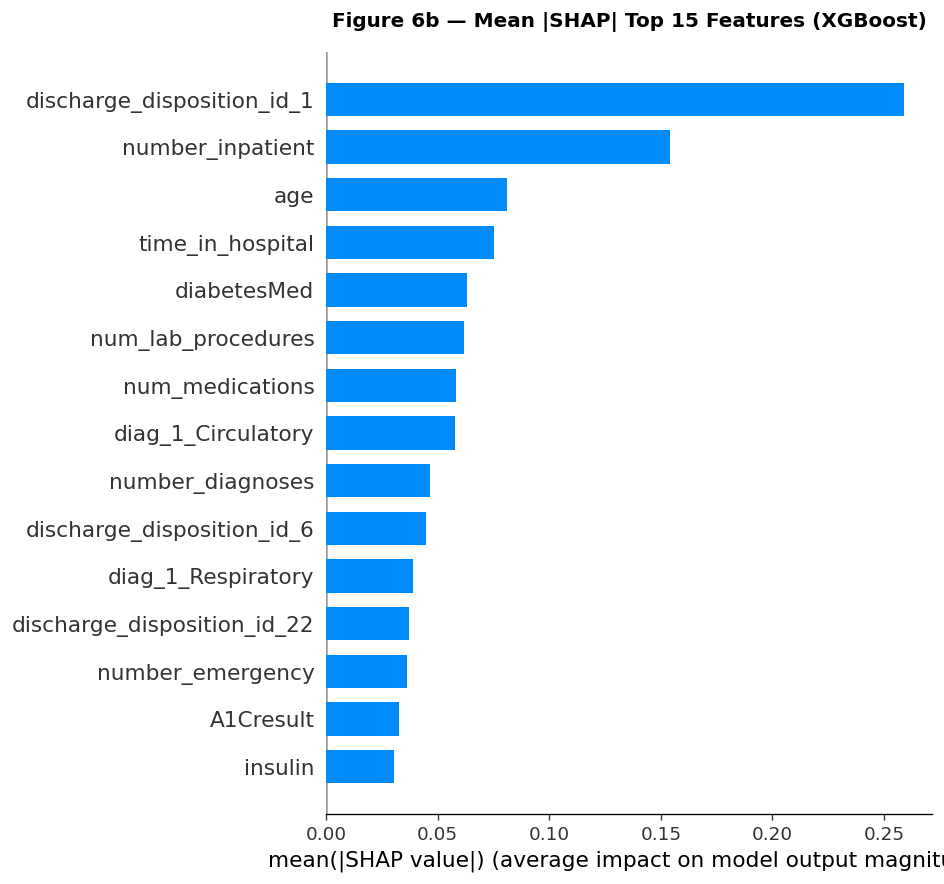

Saved: fig6b_shap_bar.png

Top 10 features by mean |SHAP| (XGBoost):
discharge_disposition_id_1    0.2588
number_inpatient              0.1542
age                           0.0812
time_in_hospital              0.0753
diabetesMed                   0.0629
num_lab_procedures            0.0617
num_medications               0.0583
diag_1_Circulatory            0.0578
number_diagnoses              0.0466
discharge_disposition_id_6    0.0447
Saved: shap_importance.csv

── Gender: MDI vs SHAP rank ─────────────────────────────────
  XGBoost MDI rank:  #53 of 110  (MDI = 0.00908)
  SHAP rank:         #29 of 110  (mean |SHAP| = 0.01261)


In [27]:
try:
    import xgboost as xgb
    import shap

    xgb_pipe  = best_models['XGBoost']
    xgb_model = xgb_pipe.named_steps['model']
    preproc   = xgb_pipe.named_steps['preprocess']

    sample_n = min(1000, len(X_test))
    X_sample_raw = X_test.iloc[:sample_n].reset_index(drop=True)

    # Run X_sample through the preprocessor → one-hot encoded numeric array
    X_sample_enc = preproc.transform(X_sample_raw)

    # Get feature names from the preprocessor (one-hot expanded)
    feat_names = preproc.get_feature_names_out()
    feat_names = [n.split('__', 1)[1] if '__' in n else n for n in feat_names]

    # Wrap as DataFrame so summary_plot displays feature names
    X_sample_df = pd.DataFrame(X_sample_enc, columns=feat_names)

    # XGBoost native TreeSHAP on the encoded matrix
    dmatrix = xgb.DMatrix(X_sample_df)
    sv_raw  = xgb_model.get_booster().predict(dmatrix, pred_contribs=True)
    sv      = sv_raw[:, :-1]   # drop bias column

    # ── Figure 6a: Beeswarm ────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_sample_df, max_display=15, show=False)
    plt.title('Figure 6a — SHAP Beeswarm (XGBoost, Readmission <30 days)',
              fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('fig6a_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig6a_shap_beeswarm.png")

    # ── Figure 6b: Bar plot ────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_sample_df, plot_type='bar', max_display=15, show=False)
    plt.title('Figure 6b — Mean |SHAP| Top 15 Features (XGBoost)',
              fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('fig6b_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig6b_shap_bar.png")

    mean_shap = pd.Series(
        np.abs(sv).mean(axis=0),
        index=feat_names
    ).sort_values(ascending=False)
    print("\nTop 10 features by mean |SHAP| (XGBoost):")
    print(mean_shap.head(10).round(4).to_string())

    mean_shap.head(15).to_csv('shap_importance.csv')
    print("Saved: shap_importance.csv")

    # ── Gender: MDI vs SHAP rank comparison ────────────────────────────────
    xgb_mdi = pd.Series(
        xgb_model.feature_importances_,
        index=feat_names
    ).sort_values(ascending=False)

    if 'gender' in xgb_mdi.index and 'gender' in mean_shap.index:
        gender_mdi_rank  = list(xgb_mdi.index).index('gender') + 1
        gender_shap_rank = list(mean_shap.index).index('gender') + 1
        print(f"\n── Gender: MDI vs SHAP rank ─────────────────────────────────")
        print(f"  XGBoost MDI rank:  #{gender_mdi_rank} of {len(xgb_mdi)}  (MDI = {xgb_mdi['gender']:.5f})")
        print(f"  SHAP rank:         #{gender_shap_rank} of {len(mean_shap)}  (mean |SHAP| = {mean_shap['gender']:.5f})")

except ImportError:
    print("shap not installed. Run:  pip install shap  then re-run this cell.")
except Exception as e:
    print(f"SHAP error: {e}")
    print("Skipping SHAP — all other results are unaffected.")

### Individual Patient Explanations (SHAP Waterfall)

Beyond aggregate feature importance, SHAP enables decomposition of each individual prediction into its contributing features. Waterfall plots are shown for three representative patients selected by percentile rank within the test set: a true positive (correctly flagged high-risk readmission), a true negative (correctly flagged low-risk), and a false positive (high predicted risk but no readmission). The aim is to demonstrate that the model's predictions are clinically interpretable at the patient level.


Predicted probability range: 0.106 to 0.875
Median: 0.444,  90th percentile: 0.628
Positive cases in sample: 107/1000



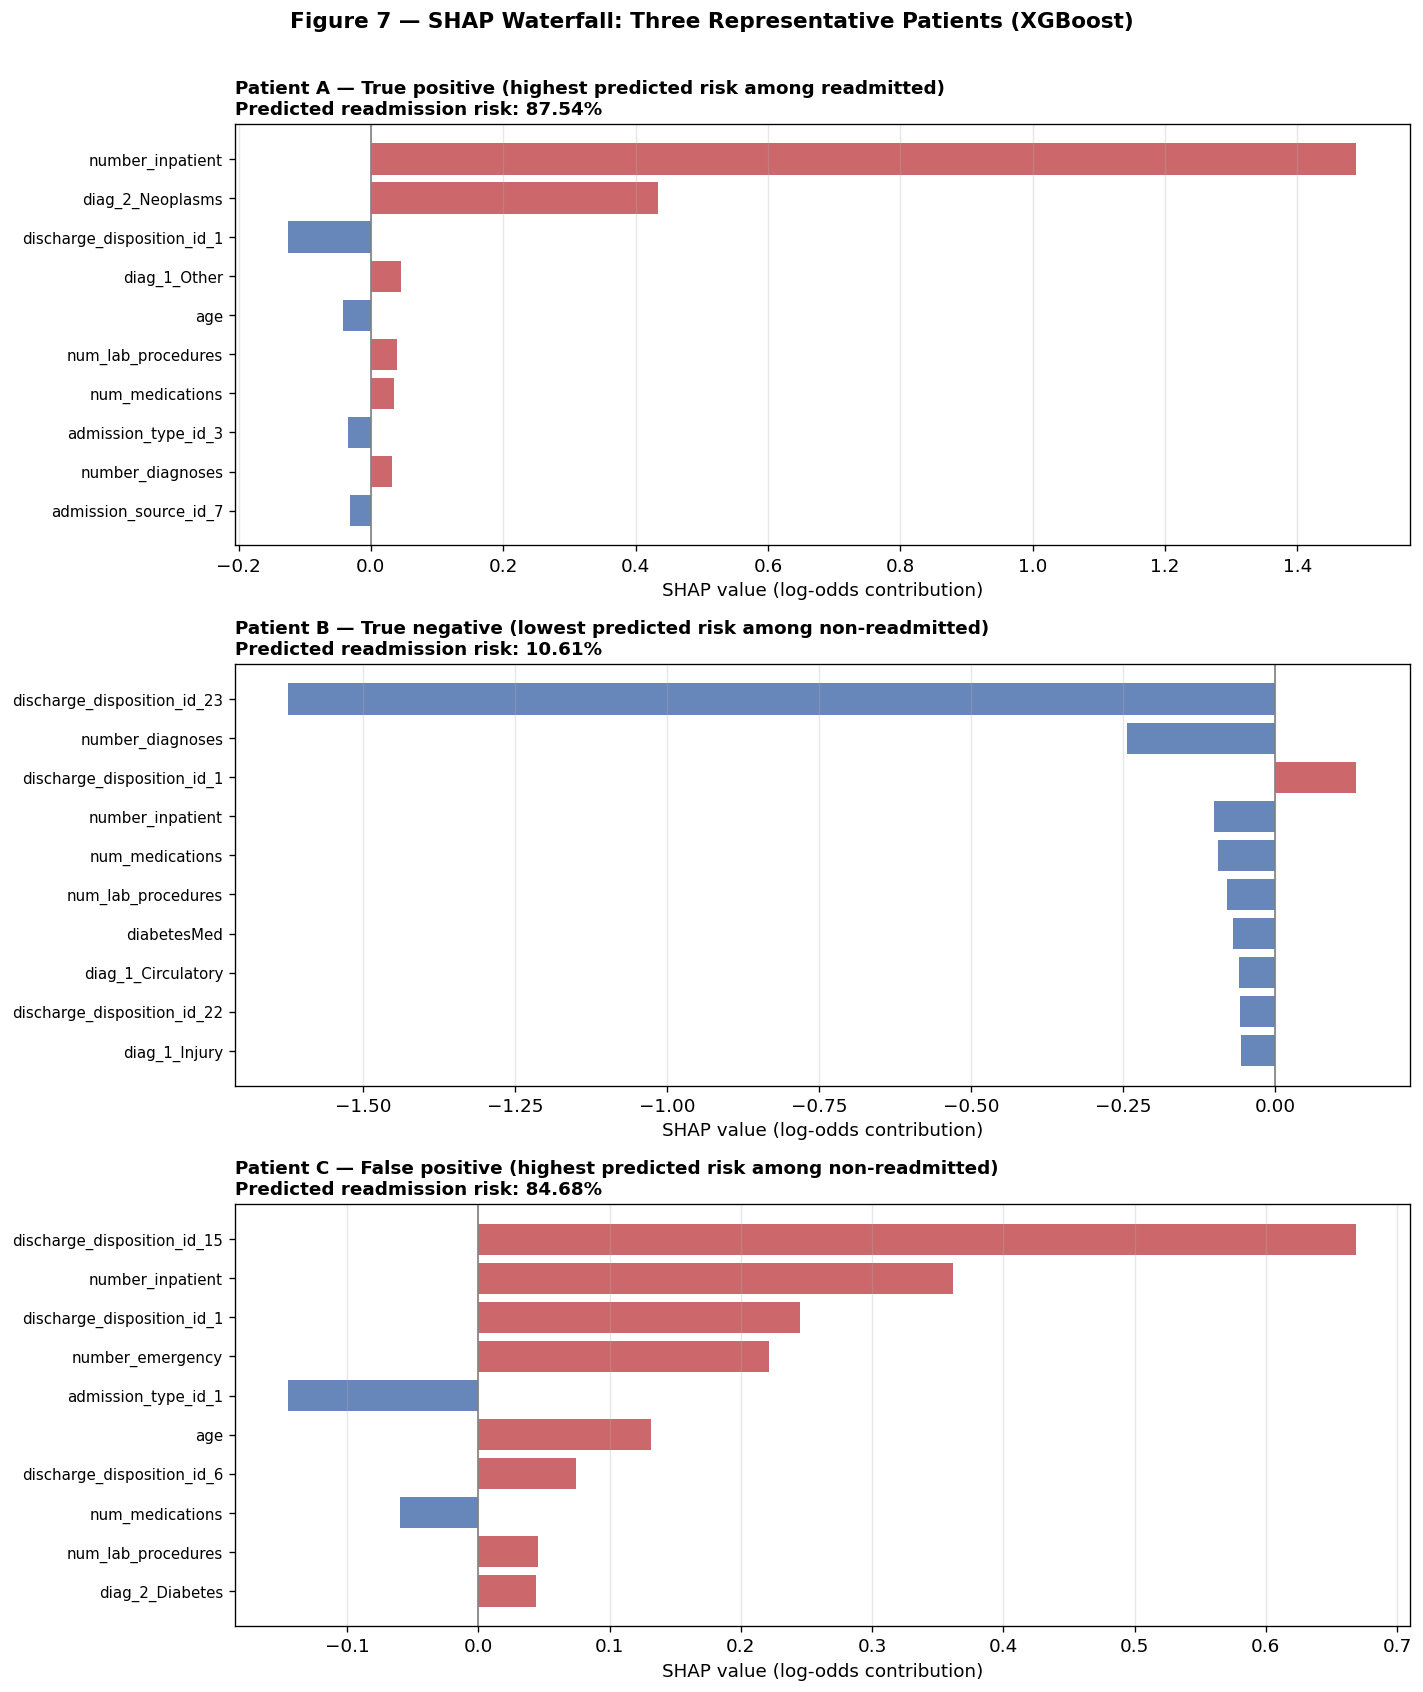

Saved: fig7_shap_waterfall.png

Selected patients:
  Patient A — True positive (highest predicted risk among readmitted)
    Index 559, predicted risk 87.54%, actual readmitted = 1
  Patient B — True negative (lowest predicted risk among non-readmitted)
    Index 666, predicted risk 10.61%, actual readmitted = 0
  Patient C — False positive (highest predicted risk among non-readmitted)
    Index 10, predicted risk 84.68%, actual readmitted = 0


In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# SHAP waterfall plots for representative patients (percentile-based selection)
# ═══════════════════════════════════════════════════════════════════════════════
try:
    import shap
    import xgboost as xgb

    xgb_pipe   = best_models['XGBoost']
    xgb_model  = xgb_pipe.named_steps['model']
    preproc    = xgb_pipe.named_steps['preprocess']

    sample_n     = min(1000, len(X_test))
    X_sample_raw = X_test.iloc[:sample_n].reset_index(drop=True)
    y_sample     = y_test.iloc[:sample_n].reset_index(drop=True)
    X_sample_enc = preproc.transform(X_sample_raw)
    feat_names   = preproc.get_feature_names_out()
    feat_names   = [n.split('__', 1)[1] if '__' in n else n for n in feat_names]
    X_sample_df  = pd.DataFrame(X_sample_enc, columns=feat_names)

    booster = xgb_model.get_booster()
    dmatrix = xgb.DMatrix(X_sample_df)
    sv       = booster.predict(dmatrix, pred_contribs=True)
    base_val = sv[0, -1]
    sv_only  = sv[:, :-1]

    yp = xgb_pipe.predict_proba(X_sample_raw)[:, 1]

    # Diagnostic
    print(f"Predicted probability range: {yp.min():.3f} to {yp.max():.3f}")
    print(f"Median: {np.median(yp):.3f},  90th percentile: {np.percentile(yp, 90):.3f}")
    print(f"Positive cases in sample: {y_sample.sum()}/{len(y_sample)}\n")

    # Percentile-based selection (always finds someone)
    # High-risk true positive: highest predicted risk among patients who actually readmitted
    pos_idx     = np.where(y_sample == 1)[0]
    high_pos    = pos_idx[np.argmax(yp[pos_idx])]   # the truly-positive patient with highest predicted risk

    # Low-risk true negative: lowest predicted risk among patients who did NOT readmit
    neg_idx     = np.where(y_sample == 0)[0]
    low_neg     = neg_idx[np.argmin(yp[neg_idx])]

    # False positive: highest predicted risk among patients who did NOT readmit
    high_neg    = neg_idx[np.argmax(yp[neg_idx])]

    patients = [
        ('Patient A — True positive (highest predicted risk among readmitted)', high_pos),
        ('Patient B — True negative (lowest predicted risk among non-readmitted)', low_neg),
        ('Patient C — False positive (highest predicted risk among non-readmitted)', high_neg)
    ]

    fig, axes = plt.subplots(3, 1, figsize=(12, 14))
    for ax, (title, idx) in zip(axes, patients):
        shap_vals = sv_only[idx]
        order     = np.argsort(np.abs(shap_vals))[-10:]
        names     = [feat_names[i] for i in order]
        vals      = shap_vals[order]
        colors    = ['#C44E52' if v > 0 else '#4C72B0' for v in vals]

        ax.barh(range(len(names)), vals, color=colors, alpha=0.85)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=9)
        ax.axvline(0, color='grey', lw=1)
        ax.set_title(f"{title}\nPredicted readmission risk: {yp[idx]:.2%}",
                     fontsize=11, fontweight='bold', loc='left')
        ax.set_xlabel('SHAP value (log-odds contribution)')
        ax.grid(axis='x', alpha=0.3)

    plt.suptitle('Figure 7 — SHAP Waterfall: Three Representative Patients (XGBoost)',
                 fontsize=13, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.savefig('fig7_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig7_shap_waterfall.png")

    print("\nSelected patients:")
    for title, idx in patients:
        print(f"  {title}")
        print(f"    Index {idx}, predicted risk {yp[idx]:.2%}, actual readmitted = {int(y_sample[idx])}")

except Exception as e:
    print(f"SHAP waterfall error: {e}")

## 13. Comparison with LACE-proxy Clinical Risk Score

The LACE index (van Walraven et al., 2010) is a four-component clinical risk score widely used for 30-day readmission prediction in general inpatient cohorts. We compute a LACE-proxy on the test set using **L**ength of stay, **A**cuity of admission, **C**omorbidity (approximated by `number_diagnoses` since exact Charlson scoring requires raw ICD-9 codes not preserved after diagnosis grouping), and **E**mergency department visits. The LACE-proxy AUC is then compared head-to-head against the three calibrated ML models, directly testing whether machine learning offers a meaningful advantage over an established clinical risk score in this diabetic cohort.


LACE score distribution (test set):
count    13995.00
mean         6.90
std          2.54
min          1.00
25%          5.00
50%          7.00
75%          9.00
max         15.00
dtype: float64

LACE AUC-ROC: 0.5504

Head-to-head benchmark vs LACE-proxy:
                           Model    AUC  AUPRC
     LACE-proxy (clinical score) 0.5504 0.1009
Logistic Regression (calibrated) 0.6494 0.1678
      Random Forest (calibrated) 0.6566 0.1775
            XGBoost (calibrated) 0.6545 0.1785


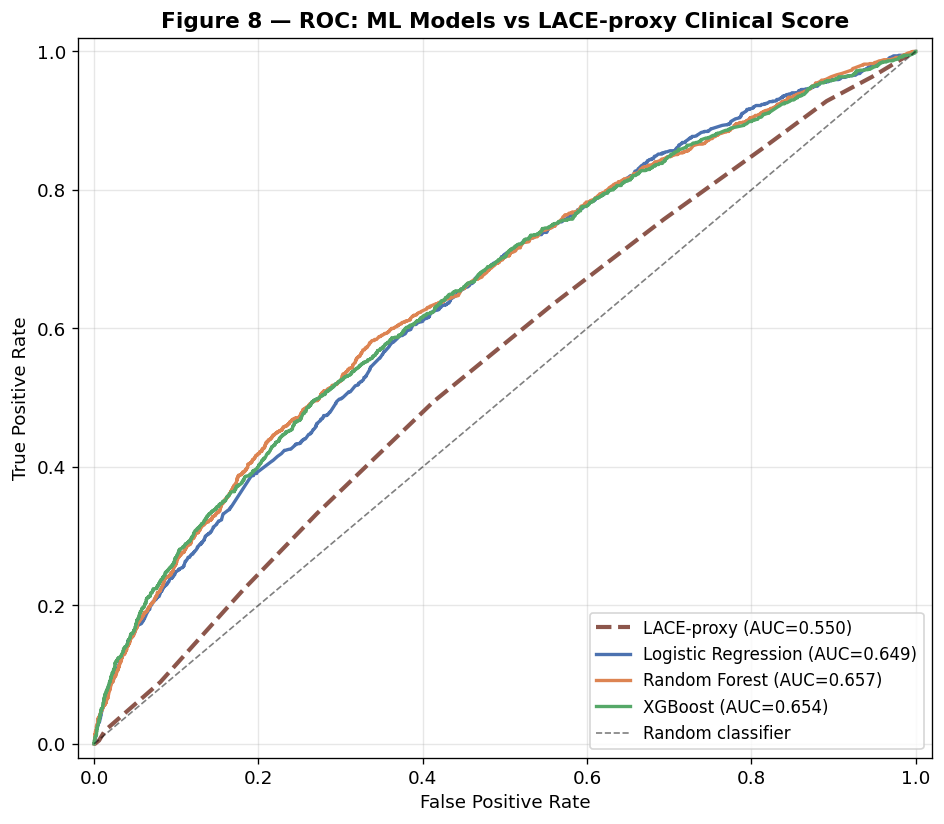

Saved: fig8_lace_comparison.png


In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# LACE-proxy benchmark comparison
# ═══════════════════════════════════════════════════════════════════════════════
# Components: L (length of stay), A (acuity), C (comorbidity), E (ED visits)
# Note: exact Charlson scoring requires specific ICD-9 codes lost during diagnosis
# grouping; comorbidity is approximated by number_diagnoses as a clinical proxy.

def lace_proxy(row):
    # L — Length of stay
    los = row['time_in_hospital']
    if   los < 1:       l = 0
    elif los == 1:      l = 1
    elif los == 2:      l = 2
    elif los == 3:      l = 3
    elif los <= 6:      l = 4
    elif los <= 13:     l = 5
    else:               l = 7

    # A — Acuity (emergent admission)
    a = 3 if str(row['admission_type_id']) in ('1', '7') else 0

    # C — Comorbidity proxy via number_diagnoses
    nd = row['number_diagnoses']
    if   nd <= 3:   c = 0
    elif nd <= 6:   c = 1
    elif nd <= 8:   c = 2
    elif nd <= 10:  c = 3
    else:           c = 5

    # E — Emergency department visits in past 6 months (capped at 4)
    e = min(int(row['number_emergency']), 4)

    return l + a + c + e

lace_test = X_test.apply(lace_proxy, axis=1)
print(f"LACE score distribution (test set):")
print(lace_test.describe().round(2))
print(f"\nLACE AUC-ROC: {roc_auc_score(y_test, lace_test):.4f}")

# ── Head-to-head AUC comparison ──────────────────────────────────────────────
comparison = []
comparison.append({'Model': 'LACE-proxy (clinical score)',
                   'AUC': round(roc_auc_score(y_test, lace_test), 4),
                   'AUPRC': round(average_precision_score(y_test, lace_test), 4)})

for name, cal_model in calibrated_models.items():
    yp = cal_model.predict_proba(X_test)[:, 1]
    comparison.append({'Model': name + ' (calibrated)',
                       'AUC': round(roc_auc_score(y_test, yp), 4),
                       'AUPRC': round(average_precision_score(y_test, yp), 4)})

comparison_df = pd.DataFrame(comparison)
print("\n" + "="*60)
print("Head-to-head benchmark vs LACE-proxy:")
print(comparison_df.to_string(index=False))
print("="*60)

# ── Figure 9: ROC curves — ML models vs LACE-proxy ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

fpr, tpr, _ = roc_curve(y_test, lace_test)
ax.plot(fpr, tpr, lw=2.5, linestyle='--', color='#8C564B',
        label=f"LACE-proxy (AUC={roc_auc_score(y_test, lace_test):.3f})")

for i, (name, cal_model) in enumerate(calibrated_models.items()):
    yp = cal_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax.plot(fpr, tpr, lw=2, color=list(PALETTE.values())[i],
            label=f"{name} (AUC={roc_auc_score(y_test, yp):.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 8 — ROC: ML Models vs LACE-proxy Clinical Score',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_lace_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_lace_comparison.png")

comparison_df.to_csv('lace_comparison.csv', index=False)

## 14. Fairness Audit by Racial Subgroup

Evaluates **all three models** separately for each racial subgroup in the test set.

Motivated by Obermeyer et al. (2019) and Stabellini et al. (2023): aggregate AUC can mask clinically significant performance disparities across demographic groups, with real-world consequences for resource allocation.

Fairness criteria assessed:
- **Equal Opportunity**: recall (sensitivity) parity across groups  
- **Predictive Parity**: precision parity across groups  
- **AUC gap**: maximum − minimum AUC across groups


In [39]:
# Compute fairness metrics for all three models
fairness_all = {}

for name, res in test_results.items():
    rows = []
    for race_val in race_decoded.unique():
        mask   = race_decoded == race_val
        n      = mask.sum()
        if n < 30: continue
        y_r    = y_test[mask]
        prob_r = res['y_proba'][mask.values]
        pred_r = res['y_pred'][mask.values]
        if y_r.nunique() < 2: continue
        rep = classification_report(y_r, pred_r, output_dict=True, zero_division=0)
        rows.append({
            'Race':          race_val,
            'N':             n,
            'Pos Rate':      round(y_r.mean(), 3),
            'AUC-ROC':       round(roc_auc_score(y_r, prob_r), 4),
            'Precision':     round(rep['1']['precision'], 4),
            'Recall':        round(rep['1']['recall'], 4),
            'F1':            round(rep['1']['f1-score'], 4),
        })
    fairness_all[name] = pd.DataFrame(rows).sort_values('N', ascending=False)

# Display each table
for name, df_f in fairness_all.items():
    print(f"\n{'='*55}  {name}")
    print(df_f.to_string(index=False))
    auc_gap = df_f['AUC-ROC'].max() - df_f['AUC-ROC'].min()
    print(f"  Max AUC gap: {auc_gap:.4f}")



=======================================================  Logistic Regression
           Race     N  Pos Rate  AUC-ROC  Precision  Recall     F1
      Caucasian 10509     0.091   0.6384     0.1332  0.5156 0.2118
AfricanAmerican  2504     0.090   0.6708     0.1543  0.4978 0.2355
        Missing   364     0.052   0.6953     0.1031  0.5263 0.1724
       Hispanic   299     0.097   0.6921     0.2394  0.5862 0.3400
          Other   231     0.048   0.6401     0.0755  0.3636 0.1250
          Asian    88     0.125   0.8087     0.3182  0.6364 0.4242
  Max AUC gap: 0.1703

=======================================================  Random Forest
           Race     N  Pos Rate  AUC-ROC  Precision  Recall     F1
      Caucasian 10509     0.091   0.6431     0.2072  0.2562 0.2292
AfricanAmerican  2504     0.090   0.6689     0.2020  0.1822 0.1916
        Missing   364     0.052   0.7645     0.3478  0.4211 0.3810
       Hispanic   299     0.097   0.7201     0.3333  0.2759 0.3019
          Other   231   

## 15. Summary Results Table

In [40]:
rows = []
for name, res in test_results.items():
    r = res['report']
    rows.append({
        'Model':             name,
        'Accuracy':          round(r['accuracy'], 4),
        'Precision (cls 1)': round(r['1']['precision'], 4),
        'Recall (cls 1)':    round(r['1']['recall'], 4),
        'F1 (cls 1)':        round(r['1']['f1-score'], 4),
        'AUC-ROC':           round(res['auc'], 4),
        'AUPRC':             round(res['auprc'], 4),
        'Brier Score':       round(res['brier'], 4),
        'CV AUC (mean)':     round(cv_results[name]['test_roc_auc'].mean(), 4),
        'CV AUC (std)':      round(cv_results[name]['test_roc_auc'].std(), 4),
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv('model_summary.csv', index=False)
print("Saved: model_summary.csv")
summary_df


Saved: model_summary.csv


,Model,Accuracy,Precision (cls 1),Recall (cls 1),F1 (cls 1),AUC-ROC,AUPRC,Brier Score,CV AUC (mean),CV AUC (std)
0,Logistic Regression,0.6678,0.1377,0.5139,0.2172,0.6488,0.1679,0.2284,0.6494,0.0059
1,Random Forest,0.8502,0.2110,0.2446,0.2266,0.6537,0.1774,0.1554,0.6540,0.0056
2,XGBoost,0.6677,0.1418,0.5355,0.2242,0.6508,0.1793,0.2163,0.6511,0.0052


In [36]:
# Export all key numbers as JSON for easy reference when writing the report
results_export = {}
for name, res in test_results.items():
    r = res['report']
    results_export[name] = {
        'test_accuracy':    round(r['accuracy'], 4),
        'test_precision':   round(r['1']['precision'], 4),
        'test_recall':      round(r['1']['recall'], 4),
        'test_f1':          round(r['1']['f1-score'], 4),
        'test_auc_roc':     round(res['auc'], 4),
        'test_auprc':       round(res['auprc'], 4),
        'test_brier':       round(res['brier'], 4),
        'cv_auc_mean':      round(cv_results[name]['test_roc_auc'].mean(), 4),
        'cv_auc_std':       round(cv_results[name]['test_roc_auc'].std(), 4),
    }

with open('results_for_report.json', 'w') as f:
    json.dump(results_export, f, indent=2)

print("Saved: results_for_report.json")
print(json.dumps(results_export, indent=2))


Saved: results_for_report.json
{
  "Logistic Regression": {
    "test_accuracy": 0.6678,
    "test_precision": 0.1377,
    "test_recall": 0.5139,
    "test_f1": 0.2172,
    "test_auc_roc": 0.6488,
    "test_auprc": 0.1679,
    "test_brier": 0.2284,
    "cv_auc_mean": 0.6494,
    "cv_auc_std": 0.0059
  },
  "Random Forest": {
    "test_accuracy": 0.8502,
    "test_precision": 0.211,
    "test_recall": 0.2446,
    "test_f1": 0.2266,
    "test_auc_roc": 0.6537,
    "test_auprc": 0.1774,
    "test_brier": 0.1554,
    "cv_auc_mean": 0.654,
    "cv_auc_std": 0.0056
  },
  "XGBoost": {
    "test_accuracy": 0.6677,
    "test_precision": 0.1418,
    "test_recall": 0.5355,
    "test_f1": 0.2242,
    "test_auc_roc": 0.6508,
    "test_auprc": 0.1793,
    "test_brier": 0.2163,
    "cv_auc_mean": 0.6511,
    "cv_auc_std": 0.0052
  }
}


---
## Output Files Generated

| File | Contents |
|---|---|
| `fig_eda.png` | EDA — class distribution, age, time in hospital, medications, inpatient visits, diagnoses |
| `fig_correlation.png` | Feature correlation heatmap |
| `fig_cv_performance.png` | 5-fold CV metric comparison |
| `fig1_roc_pr.png` | ROC and Precision-Recall curves (test set) |
| `fig2_confusion_matrices.png` | Normalised confusion matrices |
| `fig3_calibration.png` | Calibration curves + Brier scores |
| `fig4_dca.png` | Decision curve analysis |
| `fig5_feature_importance.png` | RF and XGBoost MDI importances |
| `fig6a_shap_beeswarm.png` | SHAP beeswarm — XGBoost |
| `fig6b_shap_bar.png` | SHAP mean \|SHAP\| bar — XGBoost |
| `fig7_fairness_audit.png` | Fairness audit by race — all 3 models |
| `model_summary.csv` | Full test set metrics table |
| `shap_importance.csv` | Top 15 SHAP importances |
| `results_for_report.json` | All key numbers for report writing |

## Key Methodological Improvements Over Original Notebook

1. **Weighting-only imbalance handling** — `class_weight='balanced'` (LR/RF) and `scale_pos_weight` (XGB); SMOTE deliberately not used to avoid double class-correction
2. **One-hot encoding of nominal variables** — fitted inside the pipeline to prevent leakage; enables fair LR/RF/XGB comparison
3. **Corrected ICD-9 diabetes mapping** — uses 250 ≤ val < 251 to capture all 250.xx codes
4. **Hyperparameter search** via `RandomizedSearchCV` — justified parameter choices
5. **Third model (XGBoost)** — gradient boosting enables richer model comparison
6. **Wilcoxon signed-rank tests** — statistical significance of CV AUC differences
7. **Calibration curves + Brier scores** — probability reliability assessment
8. **Decision Curve Analysis** — net clinical benefit across decision thresholds
9. **SHAP on XGBoost** — directional, interaction-aware feature attribution
10. **Fairness audit on all 3 models** — not just RF
11. **All figures saved to disk** — ready for report embedding
12. **results_for_report.json** — every number needed for the report in one place
